# DML Inference: Impact of 401(k) on Financial Wealth

In this real-data example, we illustrate how the DML package can be used to estimate the effect of 401(k) eligibility and participation on accumulated assets. The 401(k) data set has been analyzed in several studies, among others Chernozhukov et al. (2018).

401(k) plans are pension accounts sponsored by employers. The key problem in determining the effect of participation in 401(k) plans on accumulated assets is saver heterogeneity coupled with the fact that the decision to enroll in a 401(k) is non-random. It is generally recognized that some people have a higher preference for saving than others. It also seems likely that those individuals with high unobserved preference for saving would be most likely to choose to participate in tax-advantaged retirement savings plans and would tend to have otherwise high amounts of accumulated assets. The presence of unobserved savings preferences with these properties then implies that conventional estimates that do not account for saver heterogeneity and endogeneity of participation will be biased upward, tending to overstate the savings effects of 401(k) participation.

One can argue that eligibility for enrolling in a 401(k) plan in this data can be taken as exogenous after conditioning on a few observables of which the most important for their argument is income. The basic idea is that, at least around the time 401(k)’s initially became available, people were unlikely to be basing their employment decisions on whether an employer offered a 401(k) but would instead focus on income and other aspects of the job.

## DATA

In [3]:
import pandas as pd

# Replace 'your_github_raw_url_here' with the direct raw link to your CSV file on GitHub
github_csv_url = 'https://raw.githubusercontent.com/olumidesamo/econometric-iii/main/401k.csv'

# Read the CSV file directly into a pandas DataFrame
try:
    data = pd.read_csv(github_csv_url, sep=',', engine='python', index_col=0)
    print("Data loaded successfully from GitHub!")
    display(data.head())
except Exception as e:
    print(f"Error loading data from GitHub: {e}")
    print("Please ensure the URL is a direct raw link to the CSV file and the file is publicly accessible.")

# You might need to adjust the 'sep' and 'index_col' parameters based on your specific CSV file.

Data loaded successfully from GitHub!


,ira,a401,hval,hmort,hequity,nifa,net_nifa,tfa,net_tfa,tfa_he,...,i3,i4,i5,i6,i7,a1,a2,a3,a4,a5
0,0,0,69000,60150,8850,100,-3300,100,-3300,5550,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,0,78000,20000,58000,61010,61010,61010,61010,119010,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1800,0,200000,15900,184100,7549,7049,9349,8849,192949,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,0,0,0,0,2487,-6013,2487,-6013,-6013,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,300000,90000,210000,10625,-2375,10625,-2375,207625,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [4]:
data.columns

Index(['ira', 'a401', 'hval', 'hmort', 'hequity', 'nifa', 'net_nifa', 'tfa',
       'net_tfa', 'tfa_he', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr',
       'male', 'twoearn', 'dum91', 'e401', 'p401', 'pira', 'nohs', 'hs',
       'smcol', 'col', 'icat', 'ecat', 'zhat', 'net_n401', 'hown', 'i1', 'i2',
       'i3', 'i4', 'i5', 'i6', 'i7', 'a1', 'a2', 'a3', 'a4', 'a5'],
      dtype='object')

### Data Description
These data include 9,915 household-level observations extracted from the 1991 Survey of Income and Program Participation (SIPP). All variables refer to the year 1990.

In our analysis, we use Net Financial Assets (net_tfa) as the outcome variable. Net financial assets are calculated as the sum of IRA balances, 401(k) balances, checking accounts, savings bonds, other interest-earning accounts, other interest-earning assets, stocks, and mutual funds, minus non-mortgage debt.

Within the dataset:

e401: Represents eligibility for a 401(k) plan.

p401: Represents the decision to participate in a 401(k) plan.

Both are binary (0-1) variables. When the policy variable (in this case, p401) is a binary variable, the causal relationship is referred to as a "Treatment Effect."

### DATA SUMMARY



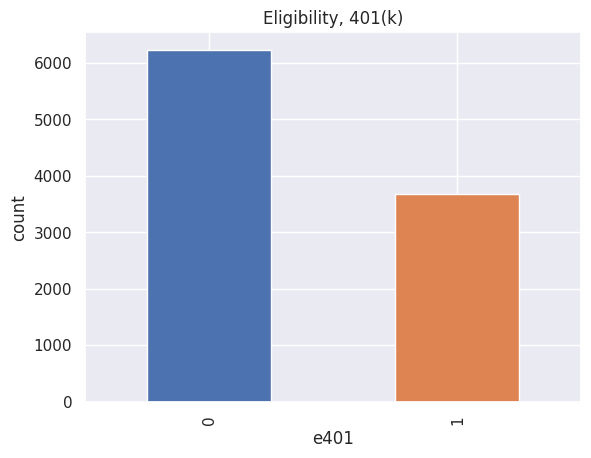

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
colors = sns.color_palette()
data['e401'].value_counts().plot(kind='bar', color=colors)
plt.title('Eligibility, 401(k)')
plt.xlabel('e401')
_ = plt.ylabel('count')

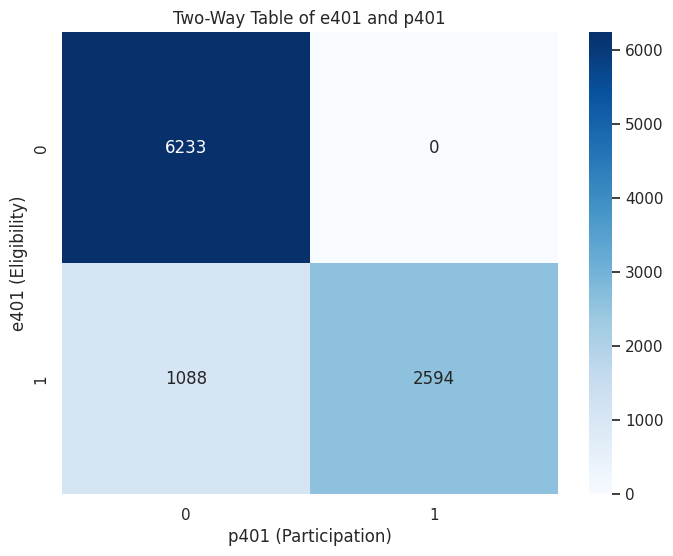

In [6]:
# Create a two-way table (contingency table)
contingency_table = pd.crosstab(data['e401'], data['p401'])

# Plot the two-way table
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.title('Two-Way Table of e401 and p401')
plt.xlabel('p401 (Participation)')
plt.ylabel('e401 (Eligibility)')
plt.show()

### Differences in means

In [7]:
# Group the data by 401(k) participation status (0 or 1)
mean_wealth_by_participation = data.groupby('p401')['net_tfa'].mean()

# Calculate the difference: Mean(net_tfa | p401=1) - Mean(net_tfa | p401=0)
naive_participation_effect = mean_wealth_by_participation.diff().iloc[1]

print(f"Naive Difference in Means (Participation): {naive_participation_effect}")


# Group the data by 401(k) participation status (0 or 1)
mean_wealth_by_elligibility = data.groupby('e401')['net_tfa'].mean()


# Calculate the difference: Mean(net_tfa | e401=1) - Mean(net_tfa | e401=0)
naive_elligibility_effect = mean_wealth_by_elligibility.diff().iloc[1]

print(f"Naive Difference in Means (Eligibility): {naive_elligibility_effect}")

Naive Difference in Means (Participation): 27371.58340367488
Naive Difference in Means (Eligibility): 19559.344749778058


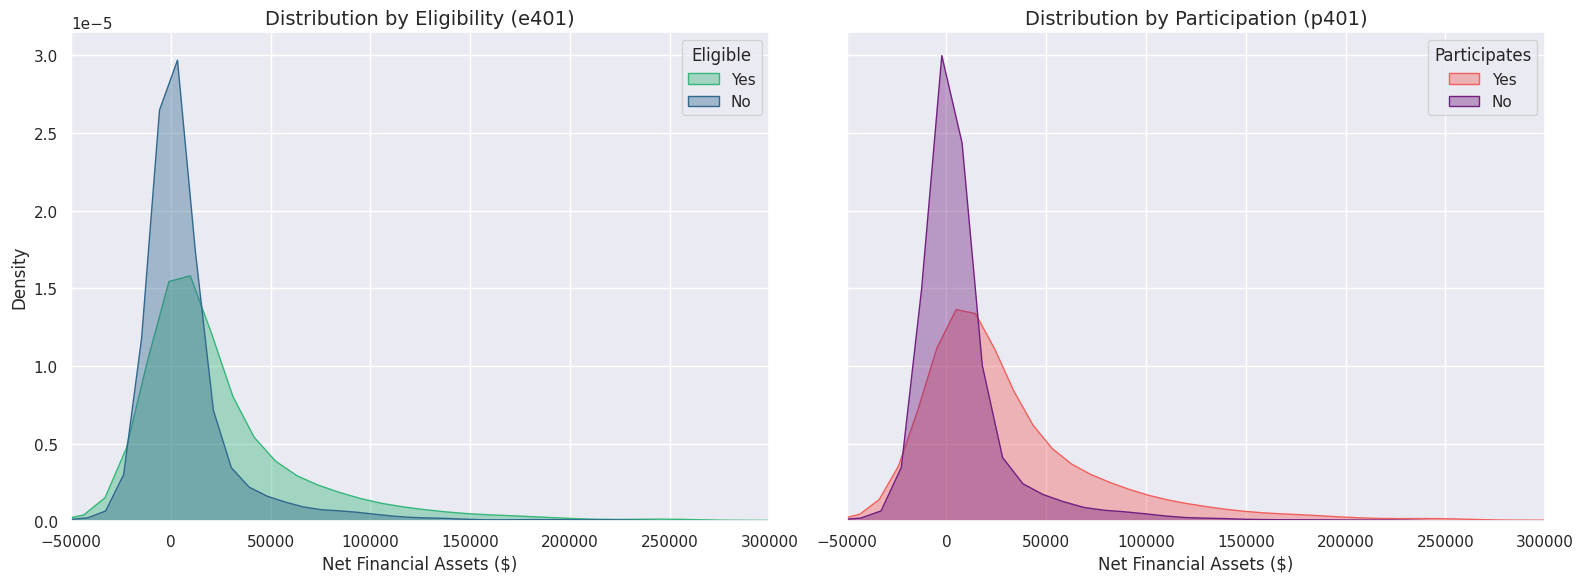

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress the FutureWarnings for a clean presentation
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# 1. Plot for Eligibility (The Instrument Z)
sns.kdeplot(
    data=data, x="net_tfa", hue="e401", fill=True, ax=axes[0],
    palette="viridis", common_norm=False, alpha=0.4
)
axes[0].set_title("Distribution by Eligibility (e401)", fontsize=14)
axes[0].set_xlabel("Net Financial Assets ($)")
axes[0].legend(title="Eligible", labels=['Yes', 'No'])

# 2. Plot for Participation (The Treatment D)
sns.kdeplot(
    data=data, x="net_tfa", hue="p401", fill=True, ax=axes[1],
    palette="magma", common_norm=False, alpha=0.4
)
axes[1].set_title("Distribution by Participation (p401)", fontsize=14)
axes[1].set_xlabel("Net Financial Assets ($)")
axes[1].legend(title="Participates", labels=['Yes', 'No'])

# Focus on the bulk of the data (ignoring extreme outliers for better visualization)
for ax in axes:
    ax.set_xlim(-50000, 300000)

plt.tight_layout()
plt.show()

## 5. The First Estimand: ATE of Eligility on Net Financial Asset

The causal effect of offering eligibility ($Z$) on the outcome ($Y$), since $Z$ is exogenous conditional on covariates $X$.

### 5.1 Regression Adjustment Estimator

$$\tau(x) = \mu(Z_i=1,X_i=x) - \mu(Z_i=0,X_i=x)$$ ATE is therefore $$\tau = \int \tau(x)dF(x)$$ where $F(x)$ is the cdf of $x$.

#### 5.1.1 Linear Regression

Assuming $$\mu(Z_i=1,X_i=x) = \mu(Z_i=0,X_i=x) = Z_i \alpha + X_i \beta$$

In [9]:
import statsmodels.api as sm
features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                 'twoearn', 'db', 'pira', 'hown']
feature = data[features_base]
X = pd.concat([feature, data[['e401']]], axis=1)
Y = data['net_tfa']
X_cons = sm.add_constant(X)
model = sm.OLS(Y,X_cons)
results = model.fit()
print(results.summary())
print('ATE：',results.params.iloc[[-1]])

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     297.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:24:18   Log-Likelihood:            -1.2242e+05
No. Observations:                9915   AIC:                         2.449e+05
Df Residuals:                    9904   BIC:                         2.449e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.291e+04   4276.223     -7.695      0.0

#### 5.1.2 Polynomial Regression


Approximating $$g(X) \approx \beta_0 + \sum_{j=1}^{p} \beta_j x_j + \sum_{j=1}^{p} \sum_{k=j}^{p} \beta_{jk} x_j x_k + \sum_{j=1}^{p} \sum_{k=j}^{p} \sum_{m=k}^{p} \beta_{jkm} x_j x_k x_m + \cdots$$

The corresponding regression model：$$Y_i=D_i \alpha + \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij} + \sum_{j=1}^{p} \sum_{k=j}^{p} \beta_{jk} x_{ij} x_{ik} + \epsilon_i$$

In [10]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=True, interaction_only=False)
feature_poly = poly.fit_transform(feature)
feature_names = poly.get_feature_names_out(input_features=feature.columns)
feature_poly = pd.DataFrame(feature_poly, columns=feature_names)
X_poly = pd.concat([feature_poly, data[['e401']]], axis=1)

model = sm.OLS(Y,X_poly)
results_ols = model.fit()
print(results_ols.summary())
print('ATE：',results_ols.params.iloc[[-1]])

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     78.98
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:24:19   Log-Likelihood:            -1.2156e+05
No. Observations:                9915   AIC:                         2.433e+05
Df Residuals:                    9846   BIC:                         2.438e+05
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
1                    -45.5747    138

#### 5.1.3 Partial Linear Model

$$Y_i = Z_i \alpha + g(X_i) + \epsilon_i$$

### The Approximate Sparsity Assumption

Consider an example where we approximate the unknown function $g(X_i)$ using high-order polynomials. Let $W_i$ represent the resulting vector of feature variables. The dimension of this vector, $k$, can be very large—potentially much larger than the sample size—which typically makes standard estimation difficult.

However, it is often the case that not all variables in $W_i$ are useful for approximating $g(X_i)$. In these scenarios, we can employ machine learning variable selection methods to identify the most relevant predictors and achieve an "optimal" approximation.

#### Formalizing the Mapping
Generalizing this logic, we define a feature mapping $T: X_i \rightarrow W_i$ that transforms a $p$-dimensional vector space into a $k$-dimensional space, where $k \gg p$. This results in the following representation:
$$g(X_i) = W_i \theta + r_i$$
where $r_i$ represents the **approximation error**.

#### The Approximate Sparsity Assumption
The **Approximate Sparsity Assumption** states that the number of non-zero coefficients $s$ in the vector $\theta$ satisfies $s < k$. Crucially:
1. We do not know a priori which specific coefficients are non-zero.
2. As the dataset grows, we can increase the model complexity (by increasing $k$) to reduce the approximation error.
3. Consequently, the error $r_i$ vanishes as the sample size $n \rightarrow \infty$.

#### Practical Application
Under this assumption, we can utilize machine learning algorithms designed for variable selection, such as **LASSO**. These algorithms identify the $s$ variables with non-zero coefficients, effectively solving the "curse of dimensionality" and addressing multi-collinearity issues inherent in high-dimensional feature spaces.

### **Naive Variable Selection**

First, let us consider the following **Naive Variable Selection Algorithm**: we define a feature mapping to obtain the vector $W_i$, and then use LASSO to estimate the linear regression model:

$$Y_i = D_i \alpha + W_i \theta + U_i$$

Below is the code implementation for this algorithm. In this specific setup, the feature mapping is constructed using **third-order polynomials** (cubic terms) of the original features:

In [11]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
poly = PolynomialFeatures(degree=3, include_bias=True, interaction_only=False)
feature_poly = poly.fit_transform(feature)
feature_names = poly.get_feature_names_out(input_features=feature.columns)
feature_poly = standard_scaler.fit_transform(feature_poly)
feature_poly = pd.DataFrame(feature_poly, columns=feature_names)
X_poly = pd.concat([feature_poly, data[['e401']]], axis=1)

reg = LassoCV(cv=3, random_state=0, max_iter=1000, tol=0.01).fit(X_poly, Y)
print("Naive Lasso coeffs：", reg.coef_)
print('ATE：',reg.coef_[-1])

Naive Lasso coeffs： [ 0.00000000e+00  0.00000000e+00 -4.45292546e+03 -1.28966107e+02
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -5.54267979e+02  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -1.43403816e+03
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00  4.06874912e+03
  0.00000000e+00  3.80393745e+03  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  1.80559116e+02 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
  9.40793617e+01  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00  8.47664222e+02
  3.04349852e+03  0.00000000e+00 -7.08042750e+02 -0.00000000e+00
 -9.3

#### **Naive ML Estimator**

##### Prompt: One-Step Naive MLP Estimator for Partial Linear Models

**Task:**
Please provide a Python implementation of a **One-Step Naive ML Estimator** for the partially linear model to demonstrate the regularization bias of the estimator:
$$Y_i = Z_i \alpha + g(X_i) + U_i$$

**Technical Requirements:**

1. **Architecture Definition:**
   - Create a Neural Network (using PyTorch or Keras) that takes both the treatment variable ($Z$) and the vector of covariates ($X$) as inputs.
   - The term $Z_i \alpha$ must be modeled as a **linear skip-connection**: a single trainable weight with no activation and no bias.
   - The nuisance function $g(X_i)$ should be modeled as a standard **Multi-Layer Perceptron (MLP)** (e.g., 2-3 hidden layers with ReLU activations).
   - The final output is the sum of these two components.

2. **Joint Optimization:**
   - The model must be trained in a single stage by minimizing the global MSE loss function:
     $$\min_{\alpha, \mathbf{w}} \frac{1}{n} \sum_{i=1}^n (Y_i - Z_i \alpha - \text{NN}(X_i; \mathbf{w}))^2$$
   - Ensure the structural parameter $\alpha$ is easily extractable after training.

3. **Code Implementation:**
   - Provide a clean, modular Python script.
   - Include a synthetic data generation step where $X$ and $Z$ are correlated (to create the confounding) so the bias can be demonstrated.
   - Include standard pre-processing steps (e.g., scaling) necessary for Neural Network convergence.

4. **The "Teachable Moment" Explanation:**
   - Provide a theoretical explanation for why this joint minimization leads to a biased $\hat{\alpha}$.
   - Focus on the "assignment problem": discuss how, during backpropagation, the flexible MLP $g(X)$ might "attribute" variation in $Y$ that actually stems from $Z$ to itself because $X$ and $Z$ are correlated.
   - Explain why this demonstrates a breakdown in the identification of the causal parameter due to the lack of Neyman Orthogonality.


In [12]:
import numpy as np
# !pip install torch torchvision torchaudio
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class PartialLinearNN(nn.Module):
    """
    Y_hat = Z alpha + g_theta(X), where g_theta is an MLP.
    alpha is a trainable linear coefficient vector.
    """
    def __init__(self, x_dim: int, z_dim: int, hidden=(128, 64), dropout=0.0):
        super().__init__()

        layers = []
        in_dim = x_dim
        for h in hidden:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.g = nn.Sequential(*layers)

        # Linear part for Z: alpha (no intercept by default; add a column of ones to Z if desired)
        self.alpha = nn.Parameter(torch.zeros(z_dim, 1))

    def forward(self, x, z):
        # x: (n, x_dim), z: (n, z_dim)
        g_x = self.g(x)                 # (n, 1)
        lin = z @ self.alpha            # (n, 1)
        return lin + g_x                # (n, 1)


def standardize(train: np.ndarray, test: np.ndarray, eps: float = 1e-8):
    mu = train.mean(axis=0, keepdims=True)
    sd = train.std(axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (train - mu) / sd, (test - mu) / sd, mu, sd


@torch.no_grad()
def predict(model, X, Z, device):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    Z_t = torch.tensor(Z, dtype=torch.float32, device=device)
    yhat = model(X_t, Z_t).cpu().numpy().reshape(-1)
    return yhat


def fit_naive_plnn(
    Y: np.ndarray,
    X: np.ndarray,
    Z: np.ndarray,
    *,
    hidden=(128, 64),
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    epochs=200,
    dropout=0.0,
    val_split=0.2,
    seed=123,
    device=None,
    verbose=True,
):
    """
    Naive ML estimator:
      minimize mean((Y - (Z alpha + NN(X)))^2) over alpha and NN parameters.

    Returns:
      model, alpha_hat (numpy), training history
    """
    assert Y.ndim == 1
    assert X.ndim == 2 and Z.ndim == 2
    n = Y.shape[0]
    assert X.shape[0] == n and Z.shape[0] == n

    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_val = int(np.floor(val_split * n))
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    # Split
    Y_tr, Y_val = Y[tr_idx], Y[val_idx]
    X_tr, X_val = X[tr_idx], X[val_idx]
    Z_tr, Z_val = Z[tr_idx], Z[val_idx]

    # Standardize X and Z (important for NN training; keep alpha interpretable only if you unscale later)
    X_tr_s, X_val_s, X_mu, X_sd = standardize(X_tr, X_val)
    Z_tr_s, Z_val_s, Z_mu, Z_sd = standardize(Z_tr, Z_val)

    # Torch tensors
    Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    Ztr_t = torch.tensor(Z_tr_s, dtype=torch.float32)
    Ytr_t = torch.tensor(Y_tr.reshape(-1, 1), dtype=torch.float32)

    Xva_t = torch.tensor(X_val_s, dtype=torch.float32)
    Zva_t = torch.tensor(Z_val_s, dtype=torch.float32)
    Yva_t = torch.tensor(Y_val.reshape(-1, 1), dtype=torch.float32)

    ds = TensorDataset(Xtr_t, Ztr_t, Ytr_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = PartialLinearNN(x_dim=X.shape[1], z_dim=Z.shape[1], hidden=hidden, dropout=dropout).to(device)
    loss_fn = nn.MSELoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = float("inf")
    best_state = None
    history = {"train_mse": [], "val_mse": []}

    for ep in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, zb, yb in dl:
            xb, zb, yb = xb.to(device), zb.to(device), yb.to(device)

            opt.zero_grad(set_to_none=True)
            yhat = model(xb, zb)
            loss = loss_fn(yhat, yb)
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            yva_hat = model(Xva_t.to(device), Zva_t.to(device))
            val_loss = loss_fn(yva_hat, Yva_t.to(device)).item()

        tr_mse = float(np.mean(train_losses))
        history["train_mse"].append(tr_mse)
        history["val_mse"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep % 25 == 0 or ep == 1 or ep == epochs):
            print(f"epoch {ep:4d} | train_mse={tr_mse:.6f} | val_mse={val_loss:.6f}")

    # Restore best
    if best_state is not None:
        model.load_state_dict(best_state)

    # alpha_hat in standardized Z-units
    alpha_hat_std = model.alpha.detach().cpu().numpy().reshape(-1)

    # Convert alpha back to original Z scale (since we standardized Z: Z_s = (Z - mu)/sd)
    # Model uses: Y ≈ (Z_s) alpha_std + g(X_s)
    # So in original Z: (Z - mu)/sd * alpha_std = Z*(alpha_std/sd) - mu*(alpha_std/sd)
    # If you included an intercept in Z, handle separately. Here: no intercept term.
    alpha_hat = alpha_hat_std / Z_sd.reshape(-1)

    out = {
        "model": model,
        "alpha_hat": alpha_hat,
        "alpha_hat_stdZ": alpha_hat_std,
        "scalers": {"X_mu": X_mu, "X_sd": X_sd, "Z_mu": Z_mu, "Z_sd": Z_sd},
        "history": history,
        "device": device,
    }
    return out


# ---------------- Example usage ----------------
if __name__ == "__main__":

    features_base = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
    Y = data['net_tfa'].values
    Z = data['e401'].values.reshape(-1, 1)  # Reshape Z to be 2-dimensional
    X = data[features_base].values

    # Fake data example
    # n, x_dim, z_dim = 5000, 10, 1
    # rng = np.random.default_rng(0)
    # X = rng.normal(size=(n, x_dim))
    # Z = 0.1 * X[:, :z_dim] + rng.normal(size=(n, z_dim))
    # alpha_true = np.array([1.5])
    # g_true = np.sin(X[:, 0]) + 0.5 * X[:, 1] ** 2
    # Y = Z @ alpha_true + g_true + rng.normal(scale=1.0, size=n)

    res = fit_naive_plnn(Y, X, Z, hidden=(128, 64), epochs=200, lr=1e-3, dropout=0.1, verbose=True)
    print("alpha_hat (original Z scale):", res["alpha_hat"])

epoch    1 | train_mse=4066936565.677419 | val_mse=5540507136.000000
epoch   25 | train_mse=3035623708.903226 | val_mse=4389220864.000000
epoch   50 | train_mse=2838014010.838710 | val_mse=4094424576.000000
epoch   75 | train_mse=2771927686.193548 | val_mse=3995758336.000000
epoch  100 | train_mse=2717938370.064516 | val_mse=3936445440.000000
epoch  125 | train_mse=2710482974.967742 | val_mse=3899845120.000000
epoch  150 | train_mse=2696202192.516129 | val_mse=3875809536.000000
epoch  175 | train_mse=2681758907.870968 | val_mse=3857608960.000000
epoch  200 | train_mse=2679319137.032258 | val_mse=3846181120.000000
alpha_hat (original Z scale): [8.97158286]


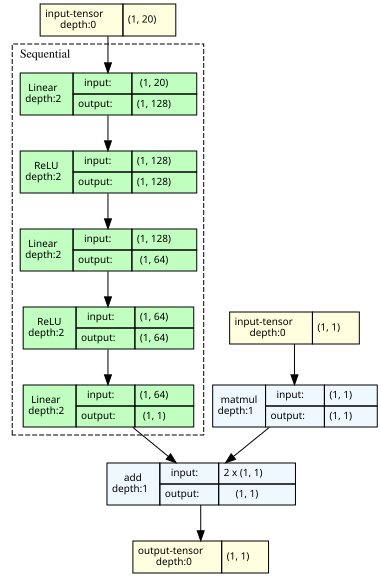

In [13]:
!pip install torchview
from torchview import draw_graph
import torch

# Initialize your model
model = PartialLinearNN(x_dim=20, z_dim=1)

# Generate the graph
# Note: we provide dummy input shapes for both X and Z
model_graph = draw_graph(
    model,
    input_data=[torch.randn(1, 20), torch.randn(1, 1)],
    expand_nested=True,
    graph_name='PartialLinearNN'
)

# Display in Jupyter/Colab or save to PDF/PNG
model_graph.visual_graph

### Special Case of DML: Double Variable Selection

To estimate the treatment effect $\alpha$ in the presence of high-dimensional controls, we employ the **Post-Double-Selection** method. This approach ensures that we include all controls that are either strong predictors of the outcome or strong predictors of treatment assignment.

### The Three-Step Procedure

1.  **Step 1: Outcome Selection (Linear Lasso)**
    Run a Linear Lasso regression of the outcome $Y$ on the high-dimensional control variables $X$.
    $$\min_{\theta} \frac{1}{n} \sum_{i=1}^n (Y_i - X_i \theta)^2 + \lambda_1 \|\theta\|_1$$
    Let $S_1$ be the set of indices for which the estimated coefficients $\hat{\theta}$ are non-zero.

2.  **Step 2: Treatment Selection (Logistic Lasso)**
    Since the treatment variable $Z$ (e.g., 401(k) eligibility) is binary, we use a Logistic Lasso to model the propensity score $P(Z=1|X)$. The $L_1$ penalty shrinks irrelevant coefficients to zero:
    $$\min_{\gamma} -\frac{1}{n} \sum_{i=1}^n \left[ Z_i \log(\Lambda(X_i \gamma)) + (1-Z_i) \log(1-\Lambda(X_i \gamma)) \right] + \lambda_2 \|\gamma\|_1$$
    where $\Lambda(\cdot)$ is the logistic CDF. Let $S_2$ be the set of indices for which the estimated coefficients $\hat{\gamma}$ are non-zero.

3.  **Step 3: Union and Post-Selection OLS**
    Construct the union of the selected variables: $W = S_1 \cup S_2$. Estimate the treatment effect $\alpha$ by running an Ordinary Least Squares (OLS) regression of $Y$ on $Z$ and the set of controls in $W$:
    $$Y_i = Z_i \alpha + W_i \gamma + \epsilon_i$$

---

### Econometric Intuition: The "Safety Net"
The "Double Selection" framework acts as a safety net against **omitted variable bias**. In high-dimensional settings, a simple "Naive" Lasso (Step 1 only) might drop a covariate that has a small effect on $Y$ but a massive correlation with $Z$. Dropping such a variable leads to traditional omitted variable bias in $\hat{\alpha}$. Step 2 (the Logit Lasso) identifies these "strong confounders," ensuring they are included in the final regression.



### Key Citations
* **Belloni, A., Chernozhukov, V., & Hansen, C. (2014).** "High-Dimensional Methods and Inference on Structural and Treatment Effects." *Journal of Economic Perspectives*, 28(2), 29-50.
* **Belloni, A., Chernozhukov, V., & Hansen, C. (2014).** "Inference on Treatment Effects after Selection amongst High-Dimensional Controls." *The Review of Economic Studies*, 81(2), 608-650.
* **Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).** "Double/debiased machine learning for treatment and structural parameters." *The Econometrics Journal*, 21(1), C1-C68.

In [8]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV, LogisticRegressionCV

import statsmodels.api as sm


def read_data(path, file, sep=",", index_col=0, encoding="utf-8"):
    return pd.read_csv(
        os.path.join(path, file),
        sep=sep,
        index_col=index_col,
        encoding=encoding,
        engine="python",
    )


def feature_mapping(df, features_base, degree=3):
    """
    Build a polynomial dictionary of X and standardize it.
    Note: include_bias=False since we'll add an intercept in the final OLS via statsmodels.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()

    X0 = df[features_base].astype(float)
    X_poly = poly.fit_transform(X0)
    names = poly.get_feature_names_out(input_features=X0.columns)

    X_poly = scaler.fit_transform(X_poly)
    return pd.DataFrame(X_poly, columns=names, index=df.index)


def _selected_from_coef(feature_names, coef, tol=1e-8):
    """
    Robustly pick selected features based on coefficient magnitude.
    Handles:
      - coef shape (p,)
      - coef shape (1,p)
      - coef shape (K,p) (multiclass): uses max abs across classes
    """
    coef = np.asarray(coef)
    if coef.ndim == 1:
        score = np.abs(coef)
    else:
        score = np.max(np.abs(coef), axis=0)

    return [name for name, s in zip(feature_names, score) if s > tol]


def feature_selection_lasso(X, y, k=5, max_iter=5000, tol=1e-4, coef_tol=1e-8):
    """
    LassoCV selection for continuous outcomes.
    """
    feature_names = list(X.columns)
    y = np.asarray(y).reshape(-1)  # ensure 1D

    model = LassoCV(cv=k, random_state=0, max_iter=max_iter, tol=tol).fit(X, y)
    return _selected_from_coef(feature_names, model.coef_, tol=coef_tol), model


def feature_selection_logit_l1(X, y, k=5, max_iter=5000, tol=1e-4, coef_tol=1e-8):
    """
    LogisticRegressionCV with L1 penalty for binary outcomes.
    """
    feature_names = list(X.columns)
    y = np.asarray(y).reshape(-1)  # ensure 1D {0,1}

    model = LogisticRegressionCV(
        cv=k,
        random_state=0,
        penalty="l1",
        solver="liblinear",
        max_iter=max_iter,
        tol=tol,
    ).fit(X, y)

    return _selected_from_coef(feature_names, model.coef_, tol=coef_tol), model


def partial_out(y, W):
    """
    Residualize y on W via least squares:
      y_res = y - W (W'W)^{-1} W' y
    Works for y as (n,) or (n,1) or (n,p).
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    W = np.asarray(W)
    B, *_ = np.linalg.lstsq(W, y, rcond=None)  # solves min ||W B - y||
    y_hat = W @ B
    return (y - y_hat)


def post_double_selection(
    y, d, X_dict,
    *,
    d_is_binary=True,
    k=5,
    max_iter=5000,
    tol=1e-4,
    coef_tol=1e-8,
    robust_se="HC3"
):
    """
    Post-Double Selection (PDS):

    Step 1 (Outcome selection, conditional on D):
      - partial out [1, D] from Y and from X
      - LASSO: y_tilde ~ X_tilde  => S_y

    Step 2 (Treatment selection):
      - if D binary: logit L1: D ~ X => S_d
        (or use LASSO on D as linear probability if you prefer strict linear theory)
      - else: LASSO: D ~ X

    Step 3 (Post-OLS):
      - OLS: Y ~ D + X_{S_y ∪ S_d} + const
    """
    # Align indices and drop missing
    df = pd.concat([y, d, X_dict], axis=1).dropna()
    yv = df[y.name].astype(float).to_numpy()
    dv = df[d.name].astype(float).to_numpy()
    Xv = df[X_dict.columns].astype(float)

    n = len(df)
    W = np.column_stack([np.ones(n), dv])  # [1, D]

    # Step 1: residualize Y and X on [1, D], then lasso select controls
    y_tilde = partial_out(yv, W).reshape(-1)
    X_tilde = partial_out(Xv.to_numpy(), W)  # (n, p)
    X_tilde_df = pd.DataFrame(X_tilde, columns=Xv.columns, index=df.index)

    S_y, lasso_y = feature_selection_lasso(
        X_tilde_df, y_tilde, k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
    )

    # Step 2: treatment selection
    if d_is_binary:
        # NOTE: for strict BCH(2014) linear-model assumptions, you can replace this with LASSO on dv.
        S_d, treat_model = feature_selection_logit_l1(
            Xv, (dv > 0.5).astype(int), k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
        )
    else:
        S_d, treat_model = feature_selection_lasso(
            Xv, dv, k=k, max_iter=max_iter, tol=tol, coef_tol=coef_tol
        )

    # Union
    S = sorted(set(S_y).union(set(S_d)))

    # Step 3: Post-OLS
    X_post = pd.concat([df[[d.name]], df[S]], axis=1)
    X_post = sm.add_constant(X_post, has_constant="add")

    ols = sm.OLS(df[y.name].astype(float), X_post).fit(cov_type=robust_se)

    return {
        "selected_outcome": S_y,
        "selected_treatment": S_d,
        "selected_union": S,
        "ols_result": ols,
        "alpha_hat_dml_plm": float(ols.params[d.name]),
        "alpha_se_dml_plm": float(ols.bse[d.name]),
    }


# ---------------- Example usage with your variables ----------------
if __name__ == "__main__":
    features_base = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
    X_dict = feature_mapping(data, features_base, degree=3)  # high-dim dictionary
    y = data['net_tfa']
    d = data['e401']
    res = post_double_selection(y, d, X_dict, d_is_binary=True)
    print("alpha_hat_dml_plm:", res["alpha_hat_dml_plm"])
    print("alpha_se_dml_plm:", res["alpha_se_dml_plm"])
    print(res["ols_result"].summary())

alpha_hat_dml_plm: 9381.251379140198
alpha_se_dml_plm: 1330.2297743132108
                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     40.53
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:14:15   Log-Likelihood:            -1.2165e+05
No. Observations:                9915   AIC:                         2.434e+05
Df Residuals:                    9865   BIC:                         2.438e+05
Df Model:                          49                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 59, but rank is 49
  warnings.warn('covariance of constraints does not have full '


# General DML Implemented by Partialing Out


$$
Y = \alpha Z + g_0(X) + U, \qquad \mathbb{E}[U \mid X, Z] = 0
$$


---

# DML via Partialing Out with Sample Splitting

## Key Idea

DML separates the estimation of the causal parameter from the estimation of the nuisance functions.

Define two nuisance functions:

Outcome regression:
$$
g_0(X) = \mathbb{E}[Y \mid X]
$$

Treatment model (propensity score for binary treatment):
$$
m_0(X) = \mathbb{E}[Z \mid X]
$$

The DML estimator first estimates these nuisance functions using machine learning and then **partial-outs their effects**.

Define residualized variables:

$$
\tilde{Y}_i = Y_i - \hat{g}(X_i)
$$

$$
\tilde{Z}_i = Z_i - \hat{m}(X_i)
$$

The treatment effect estimator is obtained from the regression:

$$
\tilde{Y}_i = \alpha \tilde{Z}_i + \varepsilon_i
$$

which yields

$$
\hat{\alpha}_{DML} =
\frac{\sum_i \tilde{Z}_i \tilde{Y}_i}
{\sum_i \tilde{Z}_i^2}
$$

This procedure removes the variation in \(Y\) and \(Z\) that can be explained by \(X\), isolating the causal relationship between the two.

---

# Sample Splitting and Cross-Fitting

A critical component of DML is **sample splitting**.

Flexible machine learning estimators can easily overfit the data.  
If the same sample is used both to estimate the nuisance functions and to estimate \(\alpha\), the residuals may inherit estimation bias.

To avoid this, DML uses **cross-fitting**:

1. Split the data into \(K\) folds.
2. For each fold \(k\):
   - Estimate \(g(X)\) and \(m(X)\) using all other folds.
   - Predict these functions on the held-out fold.
3. Construct residuals using the out-of-sample predictions.
4. Combine all folds to estimate \(\alpha\).

Cross-fitting ensures that nuisance predictions are always **out-of-sample**, which prevents overfitting bias.

---

# Neyman Orthogonality

DML relies on an **orthogonal moment condition**.

Define the score function:

$$
\psi(W; \alpha, \eta)
=
\big(Y - g(X) - \alpha (Z - m(X))\big)(Z - m(X))
$$

where  

$$
\eta = (g, m)
$$

The true parameter satisfies

$$
\mathbb{E}[\psi(W; \alpha_0, \eta_0)] = 0
$$

The key property is **Neyman orthogonality**:

$$
\left.
\frac{\partial}{\partial \eta}
\mathbb{E}[\psi(W; \alpha_0, \eta)]
\right|_{\eta = \eta_0}
= 0
$$

This means that small estimation errors in the nuisance functions affect the estimator of \(\alpha\) only at **second order**.

Consequently, machine learning estimators that converge relatively slowly can still yield **root-\(n\) consistent and asymptotically normal estimates of \(\alpha\)**.

---

# Special Case of DML: Double Variable Selection

A particularly important special case of DML is the **Post-Double-Selection method** proposed by Belloni, Chernozhukov, and Hansen.

This method is designed for high-dimensional linear settings and uses **Lasso regression** to select relevant controls.

---

# The Three-Step Double Selection Procedure

## Step 1: Outcome Selection (Linear Lasso)

Run a Lasso regression of the outcome on the controls:

$$
\min_{\theta}
\frac{1}{n}\sum_{i=1}^{n}(Y_i - X_i\theta)^2
+
\lambda_1 \|\theta\|_1
$$

Let

$$
S_1 = \{j : \hat{\theta}_j \neq 0\}
$$

be the set of variables selected as predictors of the outcome.

---

## Step 2: Treatment Selection (Logistic Lasso)

If the treatment is binary, estimate the propensity score using Logistic Lasso:

$$
\min_{\gamma}
-
\frac{1}{n}
\sum_{i=1}^{n}
\left[
Z_i \log(\Lambda(X_i\gamma))
+
(1-Z_i)\log(1-\Lambda(X_i\gamma))
\right]
+
\lambda_2 \|\gamma\|_1
$$

where  

$$
\Lambda(t) = \frac{1}{1 + e^{-t}}
$$

is the logistic function.

Define

$$
S_2 = \{j : \hat{\gamma}_j \neq 0\}
$$

as the set of predictors of treatment assignment.

---

## Step 3: Union and Post-Selection OLS

Construct the union of selected variables:

$$
W = S_1 \cup S_2
$$

Estimate the treatment effect using OLS:

$$
Y_i = Z_i \alpha + W_i \gamma + \epsilon_i
$$

The coefficient \(\hat{\alpha}\) provides the estimate of the causal effect.

---

# Econometric Intuition: The "Safety Net"

The double selection method acts as a **safety net against omitted variable bias**.

A naive Lasso regression of \(Y\) on \(X\) may drop variables that have only a weak effect on \(Y\) but are highly correlated with the treatment \(Z\).  
Dropping such variables would bias the treatment effect estimate.

The double selection procedure protects against this by including variables that predict:

1. the outcome \(Y\), and  
2. the treatment \(Z\).

By taking the **union of both sets of variables**, the method ensures that important confounders are retained in the final regression.

---

# Relationship Between Double Selection and DML

Double selection can be interpreted as a **special case of the DML partialing-out framework**.

The Frisch–Waugh–Lovell theorem shows that the coefficient \(\alpha\) from

$$
Y = \alpha Z + W\gamma + \varepsilon
$$

is equivalent to the regression:

1. Regress \(Y\) on \(W\) and compute residuals
2. Regress \(Z\) on \(W\) and compute residuals
3. Regress the residualized \(Y\) on the residualized \(Z\)

This is exactly the **partialing-out procedure** used in DML.

Thus:

- **DML** is the general framework that allows arbitrary machine learning methods for nuisance estimation.
- **Post-Double-Selection** is a sparse linear implementation of the same orthogonalization idea.

---

# Why DML Solves the Assignment Problem

In naive machine learning estimation of

$$
Y = Z\alpha + g(X)
$$

a flexible model for \(g(X)\) may absorb variation that actually belongs to the treatment term \(Z\alpha\), especially when \(Z\) is correlated with \(X\).

This creates a **regularization bias**: the model attributes part of the treatment effect to the nuisance function.

DML prevents this by removing predictable components of both variables:

$$
\tilde{Y} = Y - \hat{g}(X)
$$

$$
\tilde{Z} = Z - \hat{m}(X)
$$

The estimator then uses only the variation in \(Z\) that cannot be predicted by \(X\).

This isolates the causal signal and prevents the nuisance model from “stealing” the treatment effect.

---

# Key References

**Belloni, A., Chernozhukov, V., & Hansen, C. (2014).**  
High-Dimensional Methods and Inference on Structural and Treatment Effects.  
*Journal of Economic Perspectives*, 28(2), 29–50.

**Belloni, A., Chernozhukov, V., & Hansen, C. (2014).**  
Inference on Treatment Effects after Selection among High-Dimensional Controls.  
*Review of Economic Studies*, 81(2), 608–650.

**Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).**  
Double/Debiased Machine Learning for Treatment and Structural Parameters.  
*Econometrics Journal*, 21(1), C1–C68.

# Promt for Generating Code

**Task:**
Write a **complete Python implementation of Double Machine Learning (DML)** for the **Partially Linear Regression (PLR) model** using the **partialing-out estimator with cross-fitting**.

---

## Econometric Model

Assume the partially linear model:

$$
Y = \alpha D + g(X) + U, \qquad E[U|X,D]=0
$$

where

* (Y) is the outcome
* (D) is the treatment variable (binary or continuous)
* (X) is a high-dimensional vector of controls
* (g(X)) is an unknown nuisance function

The goal is to estimate the causal parameter ( \alpha ).

---

## Algorithm Requirements

Implement **Double Machine Learning via partialing-out with sample splitting**:

1. Estimate nuisance functions

$$
g(X) = E[Y|X]
$$

$$
m(X) = E[D|X]
$$

using machine learning.

2. Use **K-fold cross-fitting**:

   * Train nuisance models on (K-1) folds
   * Predict on the held-out fold
   * Assemble out-of-sample predictions.

3. Residualize variables:

$$
\tilde{Y}_i = Y_i - \hat g(X_i)
$$

$$
\tilde{D}_i = D_i - \hat m(X_i)
$$

4. Estimate the treatment effect

$$
\hat{\alpha} =
\frac{\frac{1}{n}\sum \tilde{D}_i\tilde{Y}_i}
{\frac{1}{n}\sum \tilde{D}_i^2}
$$

---

## Statistical Requirements

The implementation must include:

* **Orthogonal score based standard errors**

$$
\psi_i = (\tilde{Y}_i - \hat\alpha \tilde{D}_i)\tilde{D}_i
$$

$$
Var(\hat\alpha)=
\frac{1}{n}
\frac{\frac{1}{n}\sum \psi_i^2}
{\left(\frac{1}{n}\sum \tilde{D}_i^2\right)^2}
$$

* 95% confidence intervals
* two-sided p-value

---

## Machine Learning Requirements

The nuisance learners should be configurable and support:

* Lasso / Logistic Lasso
* Random Forest
* Neural Network (MLP)

Each learner should optionally support **hyperparameter tuning via cross-validation**.

---

## Engineering Requirements

The code must:

* Allow configurable parameters:

  * number of folds
  * ML algorithms
  * hyperparameter tuning
  * polynomial feature expansion

---

## Output

The function should return:

* estimated treatment effect $\hat\alpha$
* standard error
* z-statistic
* p-value
* confidence interval
* nuisance predictions $\hat g(X)$, $\hat m(X)$

---

## Deliverables

Provide:

1. Clean modular Python code
2. Clear comments explaining each step of the DML algorithm
3. Example usage on a dataset

---

## Reference

Follow the methodology of

Chernozhukov et al. (2018)
“Double/Debiased Machine Learning for Treatment and Structural Parameters”
Econometrics Journal.


In [9]:
"""
General DML (Double / Debiased Machine Learning) for the Partially Linear Model (PLR)
via partialing-out + sample splitting (cross-fitting).

Model:
    Y = alpha * D + g(X) + U,   E[U | X, D] = 0

Algorithm (PLR / partialing-out):
  1) Cross-fit nuisance learners:
        g_hat(x) ≈ E[Y|X=x]
        m_hat(x) ≈ E[D|X=x]   (propensity score if D binary)
  2) Residualize:
        y_tilde = Y - g_hat(X)
        d_tilde = D - m_hat(X)
  3) Estimate:
        alpha_hat = mean(d_tilde * y_tilde) / mean(d_tilde^2)
     with score-based robust SE.

Supports nuisance ML methods:
  - "lasso" (LassoCV / LogisticRegressionCV)
  - "rf"    (RandomForest) + optional hyperparameter tuning via RandomizedSearchCV
  - "mlp"   (sklearn MLP)  + optional hyperparameter tuning via RandomizedSearchCV

Important notes:
  - For binary D, uses StratifiedKFold (recommended).
  - Optional propensity clipping to avoid extreme predicted probabilities.
  - Any preprocessing that learns from data (scaling) is done inside fold training only.
"""

import os
import numpy as np
import pandas as pd

from math import erf, sqrt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ---------------------------------------------------------
# Data utilities (optional)
# ---------------------------------------------------------

def read_data(path, file, sep=",", index_col=0, encoding="utf-8"):
    return pd.read_csv(
        os.path.join(path, file),
        sep=sep,
        index_col=index_col,
        encoding=encoding,
        engine="python",
    )


def feature_mapping(df, features_base, degree=3, scale=False):
    """
    Polynomial feature dictionary.
    NOTE: scaling here (scale=True) would leak information across folds in strict DML usage.
    Prefer scale=False and let the ML pipelines scale within each fold.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X0 = df[features_base].astype(float)
    X_poly = poly.fit_transform(X0)
    names = poly.get_feature_names_out(input_features=X0.columns)

    if scale:
        # Not recommended for strict sample-splitting DML
        scaler = StandardScaler()
        X_poly = scaler.fit_transform(X_poly)

    return pd.DataFrame(X_poly, columns=names, index=df.index)


# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------

def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def _two_sided_p_value_from_z(z: float) -> float:
    return 2.0 * (1.0 - _norm_cdf(abs(z)))


def _to_binary_labels(d: np.ndarray) -> np.ndarray:
    """
    Convert a treatment array into 0/1 labels robustly.
    - If exactly two unique values exist, map min->0, max->1.
    - Else fall back to threshold at 0.5.
    """
    d = np.asarray(d)
    u = np.unique(d[~np.isnan(d)])
    if u.size == 2:
        hi = u.max()
        return (d == hi).astype(int)
    return (d > 0.5).astype(int)


def _default_param_distributions(model_type: str, is_classifier: bool):
    """
    Default hyperparameter search spaces for RandomizedSearchCV.
    Keys assume a Pipeline step named "model".
    """
    if model_type == "rf":
        return {
            "model__n_estimators": [200, 400, 800],
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.3, 0.5, 1.0],
        }

    if model_type == "mlp":
        # Keep the search space modest; MLP tuning can be expensive.
        return {
            "model__hidden_layer_sizes": [(64, 64), (128, 64), (256, 128)],
            "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
            "model__learning_rate_init": [2e-4, 5e-4, 1e-3, 2e-3],
            "model__batch_size": [64, 128, 256],
        }

    raise ValueError(f"No default param distributions for model_type={model_type!r}")


def build_nuisance_learner(
    model_type: str,
    *,
    is_classifier: bool,
    poly_degree: int | None = None,
    tune: bool = False,
    inner_cv: int = 3,
    n_iter: int = 20,
    random_state: int = 0,
    n_jobs: int = -1,
    param_distributions: dict | None = None,
):
    """
    Build a nuisance learner for g(X)=E[Y|X] (regression) or m(X)=E[D|X] (regression/classification).

    If tune=True and model_type in {"rf","mlp"}, wraps the pipeline in RandomizedSearchCV.
    For model_type=="lasso", uses built-in CV estimators (LassoCV / LogisticRegressionCV).
    """

    # Feature expansion step (optional)
    if poly_degree is None or poly_degree <= 1:
        poly_step = "passthrough"
    else:
        poly_step = PolynomialFeatures(degree=poly_degree, include_bias=False)

    # Choose base model
    if model_type == "lasso":
        if is_classifier:
            # Logistic L1 with CV over C (inverse regularization)
            base_model = LogisticRegressionCV(
                Cs=10,
                cv=5,
                penalty="l1",
                solver="saga",           # scalable for high-dim
                scoring="neg_log_loss",
                max_iter=5000,
                tol=1e-4,
                n_jobs=n_jobs,
                random_state=random_state,
                refit=True,
            )
        else:
            base_model = LassoCV(
                cv=5,
                n_alphas=50,
                max_iter=5000,
                tol=1e-4,
                random_state=random_state,
            )

        # Scaling is important for Lasso / logistic-lasso
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", StandardScaler()),
            ("model", base_model),
        ])

        # LassoCV/LogisticRegressionCV already do CV; no extra wrapper needed.
        return pipe

    elif model_type == "rf":
        if is_classifier:
            base_model = RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                n_jobs=n_jobs,
                random_state=random_state,
            )
        else:
            base_model = RandomForestRegressor(
                n_estimators=400,
                min_samples_leaf=5,
                n_jobs=n_jobs,
                random_state=random_state,
            )

        # RF does not need scaling; keep scaler passthrough for speed/clarity.
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", "passthrough"),
            ("model", base_model),
        ])

        if not tune:
            return pipe

        if param_distributions is None:
            param_distributions = _default_param_distributions("rf", is_classifier=is_classifier)

        scoring = "neg_log_loss" if is_classifier else "neg_mean_squared_error"
        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            refit=True,
            error_score="raise",
        )

    elif model_type == "mlp":
        if is_classifier:
            base_model = MLPClassifier(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=128,
                learning_rate_init=1e-3,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                max_iter=2000,
                random_state=random_state,
            )
        else:
            base_model = MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=128,
                learning_rate_init=1e-3,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                max_iter=2000,
                random_state=random_state,
            )

        # MLP benefits from scaling
        pipe = Pipeline([
            ("poly", poly_step),
            ("scaler", StandardScaler()),
            ("model", base_model),
        ])

        if not tune:
            return pipe

        if param_distributions is None:
            param_distributions = _default_param_distributions("mlp", is_classifier=is_classifier)

        scoring = "neg_log_loss" if is_classifier else "neg_mean_squared_error"
        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=inner_cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            refit=True,
            error_score="raise",
        )

    else:
        raise ValueError(f"Unknown model_type={model_type!r}")


# ---------------------------------------------------------
# DML PLR: partialing-out with cross-fitting
# ---------------------------------------------------------

def dml_plr_partialing_out(
    y: pd.Series,
    d: pd.Series,
    X: pd.DataFrame,
    *,
    d_is_binary: bool = True,
    ml_g: str = "rf",
    ml_m: str = "rf",
    # cross-fitting
    n_splits: int = 5,
    random_state: int = 0,
    # optional feature expansion inside folds
    poly_degree: int | None = None,
    # optional tuning (nested CV) for RF/MLP
    tune_g: bool = False,
    tune_m: bool = False,
    inner_cv: int = 3,
    n_iter: int = 20,
    n_jobs: int = -1,
    # stability
    clip_pscore: float | None = 1e-6,
    # outputs
    return_nuisance_predictions: bool = True,
    return_fold_params: bool = True,
):
    """
    DML for PLR via partialing-out with cross-fitting.

    Returns:
      dict with alpha_hat, alpha_se (score-based), CI, p-value,
      and optionally nuisance predictions and per-fold best params (if tuned).
    """

    # Ensure names exist (avoid y.name is None issues)
    y_name = y.name if y.name is not None else "Y"
    d_name = d.name if d.name is not None else "D"
    y = y.rename(y_name)
    d = d.rename(d_name)

    # Align indices and drop missing
    df = pd.concat([y, d, X], axis=1).dropna()
    Y = df[y_name].astype(float).to_numpy()
    D = df[d_name].astype(float).to_numpy()
    Xv = df[X.columns].astype(float).to_numpy()

    n = len(df)
    if n < max(50, n_splits * 10):
        # not a hard requirement, but warns about unstable folds/tuning
        pass

    # For binary D: stratified splitting improves stability
    if d_is_binary:
        D_bin = _to_binary_labels(D)
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(Xv, D_bin)
    else:
        D_bin = None
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(Xv)

    g_hat = np.empty(n, dtype=float)
    m_hat = np.empty(n, dtype=float)

    g_best_params = []
    m_best_params = []

    for fold, (tr_idx, te_idx) in enumerate(split_iter, start=1):
        X_tr, X_te = Xv[tr_idx], Xv[te_idx]
        Y_tr = Y[tr_idx]
        D_tr = D[tr_idx]

        # ----- outcome nuisance: g(x)=E[Y|X=x] -----
        g_model = build_nuisance_learner(
            ml_g,
            is_classifier=False,
            poly_degree=poly_degree,
            tune=tune_g,
            inner_cv=inner_cv,
            n_iter=n_iter,
            random_state=random_state + 1000 * fold,
            n_jobs=n_jobs,
        )
        g_model.fit(X_tr, Y_tr)
        g_hat[te_idx] = g_model.predict(X_te)

        if return_fold_params and hasattr(g_model, "best_params_"):
            g_best_params.append(g_model.best_params_)
        elif return_fold_params:
            g_best_params.append(None)

        # ----- treatment nuisance: m(x)=E[D|X=x] -----
        if d_is_binary:
            m_model = build_nuisance_learner(
                ml_m,
                is_classifier=True,
                poly_degree=poly_degree,
                tune=tune_m,
                inner_cv=inner_cv,
                n_iter=n_iter,
                random_state=random_state + 2000 * fold,
                n_jobs=n_jobs,
            )
            m_model.fit(X_tr, _to_binary_labels(D_tr))
            p = m_model.predict_proba(X_te)[:, 1]
            if clip_pscore is not None:
                p = np.clip(p, clip_pscore, 1.0 - clip_pscore)
            m_hat[te_idx] = p

            if return_fold_params and hasattr(m_model, "best_params_"):
                m_best_params.append(m_model.best_params_)
            elif return_fold_params:
                m_best_params.append(None)

        else:
            m_model = build_nuisance_learner(
                ml_m,
                is_classifier=False,
                poly_degree=poly_degree,
                tune=tune_m,
                inner_cv=inner_cv,
                n_iter=n_iter,
                random_state=random_state + 2000 * fold,
                n_jobs=n_jobs,
            )
            m_model.fit(X_tr, D_tr)
            m_hat[te_idx] = m_model.predict(X_te)

            if return_fold_params and hasattr(m_model, "best_params_"):
                m_best_params.append(m_model.best_params_)
            elif return_fold_params:
                m_best_params.append(None)

    # Residualize (partial-out)
    y_tilde = Y - g_hat
    d_tilde = D - m_hat

    # DML point estimate (no-intercept residual regression)
    denom = float(np.mean(d_tilde ** 2))
    if denom <= 1e-20:
        raise ValueError(
            "Residualized treatment has (near) zero variance. "
            "Check overlap / propensity model / clipping / data quality."
        )

    alpha_hat = float(np.mean(d_tilde * y_tilde) / denom)

    # Score-based robust SE for orthogonal score:
    # psi_i = (y_tilde - alpha_hat d_tilde) * d_tilde
    psi = (y_tilde - alpha_hat * d_tilde) * d_tilde
    var_hat = (float(np.mean(psi ** 2)) / (denom ** 2)) / n
    alpha_se = float(np.sqrt(var_hat))

    z = alpha_hat / alpha_se if alpha_se > 0 else np.inf
    p_value = float(_two_sided_p_value_from_z(z))

    ci95 = (alpha_hat - 1.96 * alpha_se, alpha_hat + 1.96 * alpha_se)

    out = {
        "n_obs": int(n),
        "alpha_hat": alpha_hat,
        "alpha_se": alpha_se,
        "z_stat": float(z),
        "p_value": p_value,
        "ci95": (float(ci95[0]), float(ci95[1])),
        "ml_g": ml_g,
        "ml_m": ml_m,
        "tune_g": bool(tune_g),
        "tune_m": bool(tune_m),
        "n_splits": int(n_splits),
        "poly_degree": None if poly_degree is None else int(poly_degree),
    }

    if return_nuisance_predictions:
        out.update({
            "g_hat": g_hat,
            "m_hat": m_hat,
            "y_tilde": y_tilde,
            "d_tilde": d_tilde,
        })

    if return_fold_params:
        out.update({
            "g_best_params_by_fold": g_best_params,
            "m_best_params_by_fold": m_best_params,
        })

    if d_is_binary:
        out.update({
            "propensity_min": float(np.min(m_hat)),
            "propensity_max": float(np.max(m_hat)),
            "propensity_mean": float(np.mean(m_hat)),
        })

    return out


# ---------------------------------------------------------
# Assignment Data
# ---------------------------------------------------------
if __name__ == "__main__":
    # Example: assuming you already have a pandas DataFrame called `data`
    # with outcome 'net_tfa', treatment 'e401', and controls listed below.

    features_base = ['age','inc','educ','fsize','marr','twoearn','db','pira','hown']
    y = data['net_tfa']
    d = data['p401']
    X = data[features_base]

    # Option A (recommended): let DML create polynomial features inside folds
    res_DML_pds = dml_plr_partialing_out(
         y, d, X,
         d_is_binary=True,
         ml_g="rf",
         ml_m="rf",
         n_splits=5,
         poly_degree=None,
         tune_g=False,     # enables RandomizedSearchCV for RF/MLP (lasso already CV's)
         tune_m=False,
         inner_cv=2,
         n_iter=5,
         clip_pscore=1e-6,
    )
    print("alpha_hat:", res_DML_pds["alpha_hat"])
    print("alpha_se :", res_DML_pds["alpha_se"])
    print("ci95     :", res_DML_pds["ci95"])
    print("p_value  :", res_DML_pds["p_value"])
    print("propensity range:", res.get("propensity_min"), res.get("propensity_max"))

    # Option B: build a polynomial dictionary externally (no scaling), then set poly_degree=None
    # X_dict = feature_mapping(data, features_base, degree=3, scale=False)
    # res = dml_plr_partialing_out(
    #     y, d, X_dict,
    #     d_is_binary=True,
    #     ml_g="lasso",
    #     ml_m="lasso",
    #     n_splits=5,
    #     poly_degree=None,
    # )

    # print("alpha_hat:", res["alpha_hat"])
    pass

alpha_hat: 14363.54402278877
alpha_se : 1483.2315144821148
ci95     : (11456.410254403825, 17270.677791173715)
p_value  : 0.0
propensity range: None None


# DML for Fully Nonparametric Treatment Effects via AIPW

This note extends Double / Debiased Machine Learning (DML) from the partially linear regression (PLR) model to the **fully nonparametric** case by using the **Augmented Inverse Probability Weighting (AIPW)** estimator and its **Neyman-orthogonal score**.

We consider the standard potential outcomes framework with a binary treatment.

---

## Setup and Target Parameter

Let:

- $Y \in \mathbb{R}$ be the observed outcome  
- $Z \in \{0,1\} $ be a binary treatment  
- $X \in \mathbb{R}^p$ be a (possibly high-dimensional) vector of covariates  
- $(Y(1), Y(0))$ be potential outcomes  

Observed outcome:
$$
Y = Z Y(1) + (1-Z) Y(0).
$$

### Parameter of Interest: ATE

The **Average Treatment Effect (ATE)** is
$$
\tau_0 = \mathbb{E}[Y(1) - Y(0)].
$$

---

## Identification Assumptions

### 1) Unconfoundedness (Selection on Observables)
$$
(Y(1), Y(0)) \perp Z \mid X.
$$

### 2) Overlap (Positivity)
There exists \(\epsilon > 0\) such that
$$
\epsilon < \mathbb{P}(Z=1 \mid X) < 1-\epsilon \quad \text{a.s.}
$$

Under these assumptions:
$$
\tau_0 = \mathbb{E}\big[\mathbb{E}[Y \mid Z=1, X] - \mathbb{E}[Y \mid Z=0, X]\big].
$$

---

## Nuisance Functions

Define the nuisance components:

### Propensity score
$$
e_0(X) = \mathbb{P}(Z=1 \mid X).
$$

### Outcome regressions
$$
\mu_1(X) = \mathbb{E}[Y \mid Z=1, X], \qquad \mu_0(X) = \mathbb{E}[Y \mid Z=0, X].
$$

Collect nuisances as
$$
\eta_0 = (\mu_0, \mu_1, e_0).
$$

---

## AIPW Estimator

The **AIPW** (Augmented Inverse Probability Weighting) estimator can be written in plug-in form as:

$$
\hat\tau_{\text{AIPW}}
=
\frac{1}{n}\sum_{i=1}^n
\left[
\hat\mu_1(X_i) - \hat\mu_0(X_i)
+
\frac{Z_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
-
\frac{(1-Z_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}
\right].
$$

### Double Robustness

AIPW is **doubly robust**

---

## Orthogonal Score Function for ATE (AIPW Score)

Let $W=(Y,Z,X)$. Define the AIPW score:

$$
\psi(W; \tau, \eta)
=
\left[
\mu_1(X) - \mu_0(X)
+
\frac{Z\,(Y - \mu_1(X))}{e(X)}
-
\frac{(1-Z)\,(Y - \mu_0(X))}{1-e(X)}
\right]
- \tau.
$$

The target parameter $\tau_0$ satisfies the moment equation:

$$
\mathbb{E}[\psi(W; \tau_0, \eta_0)] = 0.
$$

### Neyman Orthogonality

The score is **Neyman-orthogonal** with respect to nuisance perturbations:

$$
\left.
\frac{\partial}{\partial \eta}
\mathbb{E}[\psi(W; \tau_0, \eta)]
\right|_{\eta=\eta_0}
= 0.
$$

---

## DML Algorithm for AIPW (Cross-Fitted)

DML uses **sample splitting and cross-fitting** to avoid overfitting bias in nuisance estimation.

Let $K \ge 2$ and split indices into folds $I_1, \dots, I_K$.

### Step 0: Initialize
Choose ML estimators for:

- $\mu_1(X)$ using observations with $D=1$
- $\mu_0(X)$ using observations with $D=0$
- $e(X)$ using all observations (classification)

Optionally include hyperparameter tuning (CV) within each training fold.

---

### Step 1: Cross-Fit Nuisance Functions

For each fold $k \in \{1,\dots,K\}$:

- Training set: $I_k^c = \{1,\dots,n\}\setminus I_k$
- Test set: $I_k$

Fit nuisances on $I_k^c$:

Outcome regressions:
$$
\hat\mu_1^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid D=1, X=\cdot] \ \text{using } \{i\in I_k^c: D_i=1\}
$$
$$
\hat\mu_0^{(-k)}(\cdot) \approx \mathbb{E}[Y \mid D=0, X=\cdot] \ \text{using } \{i\in I_k^c: D_i=0\}
$$

Propensity model:
$$
\hat e^{(-k)}(\cdot) \approx \mathbb{P}(D=1 \mid X=\cdot) \ \text{using } \{i\in I_k^c\}
$$

Predict nuisances on the held-out fold \(I_k\):
$$
\hat\mu_1(X_i)=\hat\mu_1^{(-k)}(X_i),\quad
\hat\mu_0(X_i)=\hat\mu_0^{(-k)}(X_i),\quad
\hat e(X_i)=\hat e^{(-k)}(X_i),
\qquad i\in I_k.
$$

After looping through all folds, each observation \(i\) has nuisance predictions computed **out-of-sample**.

---

### Step 2: Compute Cross-Fitted Scores

For each observation $i$, compute the orthogonal score (with $\tau$ not yet plugged in):

$$
\hat\phi_i
=
\hat\mu_1(X_i) - \hat\mu_0(X_i)
+
\frac{D_i\,(Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
-
\frac{(1-D_i)\,(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}.
$$

Practical stabilization: clip propensity scores to enforce overlap numerically:
$$
\hat e(X_i) \leftarrow \min\{1-\epsilon, \max\{\epsilon, \hat e(X_i)\}\}
$$
for some small $\epsilon$ (e.g., $10^{-3}$ or $10^{-6}$).

---

### Step 3: Estimate the ATE

Since $\psi(W;\tau,\eta) = \hat\phi_i - \tau$, the DML estimate is simply the sample mean:

$$
\hat\tau_{\text{DML-AIPW}} = \frac{1}{n}\sum_{i=1}^n \hat\phi_i.
$$

---

## Inference (Score-Based Variance)

The orthogonal score implies a simple variance estimator.

Define:
$$
\hat\psi_i = \hat\phi_i - \hat\tau_{\text{DML-AIPW}}.
$$

Then:
$$
\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}})
=
\frac{1}{n}\cdot
\frac{1}{n}\sum_{i=1}^n \hat\psi_i^2.
$$

Standard error:
$$
\widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}})
=
\sqrt{\widehat{\mathrm{Var}}(\hat\tau_{\text{DML-AIPW}})}.
$$

A 95% confidence interval:
$$
\hat\tau_{\text{DML-AIPW}} \pm 1.96 \cdot \widehat{\mathrm{SE}}(\hat\tau_{\text{DML-AIPW}}).
$$

---

## Summary: What Changes from PLR to Fully Nonparametric DML

### PLR (Partialing-Out)
- Parameter: $\alpha$
- Nuisances: $g(X)=E[Y|X]$, $m(X)=E[D|X]$
- Residual regression: $\tilde Y \sim \tilde D$

### Fully Nonparametric ATE (AIPW)
- Parameter: $\tau = E[Y(1)-Y(0)]$
- Nuisances: $\mu_1(X), \mu_0(X), e(X)$
- Orthogonal score: AIPW score $\psi(W;\tau,\eta)$
- Estimator: sample mean of cross-fitted AIPW pseudo-outcomes

---

## References

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018).  
Double/Debiased Machine Learning for Treatment and Structural Parameters. *The Econometrics Journal*, 21(1), C1–C68.

Robins, J. M., Rotnitzky, A., & Zhao, L. P. (1994).  
Estimation of regression coefficients when some regressors are not always observed. *Journal of the American Statistical Association*.



# Mid-Term Exam Questions

1. Implement fully non-parametric Double Machine Learning to estimate the Average Treatment Effect (ATE) of 401(k) eligibility on net financial assets. Compare this estimate with the ones obtained from DML (including Post-Double-Selection) applied to a Partially Linear Model.

2. Specify a Partially Linear IV Model (PLIV) to estimate the Local Average Treatment Effect (LATE) of 401(k) participation on net financial assets, and rigorously discuss the Instrumental Variable (IV) identification strategy. Then, implement DML on your specified model to estimate this LATE.

3. Estimate the LATE of 401(k) participation on net financial assets using a fully non-parametric DML approach. Compare this estimate with the one obtained in Question 2, discussing any differences in the underlying assumptions.

****

# Solutions to the Midterm questions
## Part 1

In [13]:
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LassoCV, LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.exceptions import ConvergenceWarning


warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

# Outcome and treatment
if __name__ == "__main__":

    #
    features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                     'twoearn', 'db', 'pira', 'hown']

    cols_needed = ["net_tfa", "e401"] + features_base

    # Keep only complete cases
    df = data[cols_needed].dropna().copy()

    # Outcome
    Y = df["net_tfa"].to_numpy(dtype=float)

    # Treatment
    Z = df["e401"].to_numpy(dtype=int)

    # Covariates
    X = df[features_base].to_numpy(dtype=float)

# ------------------------------------------------------------
# 2. Learner factory
# ------------------------------------------------------------
def make_learners(model_type="lasso", random_state=123):
    """
    Returns:
        reg: regression learner for mu_0 and mu_1
        clf: classification learner for e(x)
    """

    if model_type == "lasso":
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LassoCV(cv=5, random_state=random_state, max_iter=10000))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=0.1,
                max_iter=2000,
                random_state=random_state
            ))
        ])

    elif model_type == "rf":
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=5,
                random_state=random_state,
                n_jobs=-1
            ))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=5,
                random_state=random_state,
                n_jobs=-1
            ))
        ])

    elif model_type == "mlp":
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                alpha=1e-3,
                max_iter=1500,
                random_state=random_state
            ))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                alpha=1e-3,
                max_iter=1500,
                random_state=random_state
            ))
        ])

    else:
        raise ValueError("model_type must be one of: 'lasso', 'rf', 'mlp'")

    return reg, clf


# ------------------------------------------------------------
# 3. Fully nonparametric DML-AIPW for ATE
# ------------------------------------------------------------
def dml_aipw_401k(Y, Z, X, K=5, learner="lasso", epsilon_clip=0.01, random_state=123):
    """
    Cross-fitted DML-AIPW estimator for the ATE.

    Parameters
    ----------
    Y : array-like, shape (n,)
        Outcome.
    Z : array-like, shape (n,)
        Binary treatment.
    X : array-like, shape (n, p)
        Covariates.
    K : int
        Number of folds.
    learner : str
        'lasso', 'rf', or 'mlp'.
    epsilon_clip : float
        Propensity clipping threshold.
    random_state : int
        Random seed.

    Returns
    -------
    dict with:
        ate, se, ci_low, ci_high,
        mu0_hat, mu1_hat, e_hat, phi
    """

    Y = np.asarray(Y, dtype=float)
    Z = np.asarray(Z, dtype=int)
    X = np.asarray(X, dtype=float)

    n = len(Y)

    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)
    e_hat = np.zeros(n)

    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)
    reg_base, clf_base = make_learners(learner, random_state=random_state)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Z_train = Y[train_idx], Z[train_idx]

        # Outcome model for treated
        reg1 = clone(reg_base)
        reg1.fit(X_train[Z_train == 1], Y_train[Z_train == 1])

        # Outcome model for untreated
        reg0 = clone(reg_base)
        reg0.fit(X_train[Z_train == 0], Y_train[Z_train == 0])

        # Propensity model
        clf = clone(clf_base)
        clf.fit(X_train, Z_train)

        # Out-of-fold predictions
        mu1_hat[test_idx] = reg1.predict(X_test)
        mu0_hat[test_idx] = reg0.predict(X_test)
        e_hat[test_idx] = clf.predict_proba(X_test)[:, 1]

    # Clip propensity scores for numerical stability
    e_hat = np.clip(e_hat, epsilon_clip, 1 - epsilon_clip)

    # AIPW scores
    phi = (
        mu1_hat - mu0_hat
        + Z * (Y - mu1_hat) / e_hat
        - (1 - Z) * (Y - mu0_hat) / (1 - e_hat)
    )

    ate = phi.mean()
    psi = phi - ate
    se = np.sqrt(np.mean(psi ** 2) / n)

    ci_low = ate - 1.96 * se
    ci_high = ate + 1.96 * se

    return {
        "ate": ate,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "mu0_hat": mu0_hat,
        "mu1_hat": mu1_hat,
        "e_hat": e_hat,
        "phi": phi
    }


# ------------------------------------------------------------
# 4. Partially linear DML
# ------------------------------------------------------------
def dml_plr_lasso(Y, D, X, K=5, random_state=123):
    """
    Partially Linear Regression DML :
        Y = theta * D + g(X) + U
        D = m(X) + V
    estimated by cross-fitted orthogonal score with lasso/logit-lasso.
    """

    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=int)
    X = np.asarray(X, dtype=float)
    n = len(Y)

    ghat = np.zeros(n)
    mhat = np.zeros(n)

    reg_y = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, random_state=random_state, max_iter=10000))
    ])

    reg_d = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.1,
            max_iter=2000,
            random_state=random_state
        ))
    ])

    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)

    for train_idx, test_idx in kf.split(X):
        ry = clone(reg_y).fit(X[train_idx], Y[train_idx])
        rd = clone(reg_d).fit(X[train_idx], D[train_idx])

        ghat[test_idx] = ry.predict(X[test_idx])
        mhat[test_idx] = rd.predict_proba(X[test_idx])[:, 1]

    vhat = D - mhat
    theta = np.mean(vhat * (Y - ghat)) / np.mean(vhat * D)

    score = vhat * (Y - ghat - theta * (D - mhat))
    se = np.sqrt(np.mean(score ** 2) / (np.mean(vhat * D) ** 2 * n))

    return {
        "ate": theta,
        "se": se,
        "ci_low": theta - 1.96 * se,
        "ci_high": theta + 1.96 * se
    }


# ------------------------------------------------------------
# 5. Post-Double-Selection
# ------------------------------------------------------------

def post_double_selection_lasso(Y, D, X, random_state=123):
    """
    Simple PDS benchmark:
    1. Lasso of Y on X
    2. Logit-lasso of D on X
    3. Union of selected covariates
    4. OLS of Y on D and selected X
    """

    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=int)
    X = np.asarray(X, dtype=float)
    n = len(Y)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    lasso_y = LassoCV(cv=5, random_state=random_state, max_iter=10000).fit(Xs, Y)
    logit_d = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        max_iter=2000,
        random_state=random_state
    ).fit(Xs, D)

    sel_y = np.where(np.abs(lasso_y.coef_) > 1e-8)[0]
    sel_d = np.where(np.abs(logit_d.coef_.ravel()) > 1e-8)[0]
    sel = np.union1d(sel_y, sel_d)

    X_sel = X[:, sel]
    X_ols = np.column_stack([np.ones(n), D, X_sel])

    beta = np.linalg.lstsq(X_ols, Y, rcond=None)[0]
    resid = Y - X_ols @ beta

    # HC0 robust variance
    XtX_inv = np.linalg.inv(X_ols.T @ X_ols)
    meat = X_ols.T @ np.diag(resid ** 2) @ X_ols
    vcov = XtX_inv @ meat @ XtX_inv

    ate = beta[1]
    se = np.sqrt(vcov[1, 1])

    return {
        "ate": ate,
        "se": se,
        "ci_low": ate - 1.96 * se,
        "ci_high": ate + 1.96 * se,
        "n_selected_controls": len(sel)
    }


# ------------------------------------------------------------
# 6. Run all models
# ------------------------------------------------------------
res_dml_lasso = dml_aipw_401k(Y, Z, X, K=5, learner="lasso", epsilon_clip=0.01, random_state=123)
res_dml_rf    = dml_aipw_401k(Y, Z, X, K=5, learner="rf",    epsilon_clip=0.01, random_state=123)
res_dml_mlp   = dml_aipw_401k(Y, Z, X, K=5, learner="mlp",   epsilon_clip=0.01, random_state=123)



results = pd.DataFrame([
    {
        "method": "DML-AIPW (Lasso)",
        "ATE": res_dml_lasso["ate"],
        "SE": res_dml_lasso["se"],
        "CI Low": res_dml_lasso["ci_low"],
        "CI High": res_dml_lasso["ci_high"],
    },
    {
        "method": "DML-AIPW (Random Forest)",
        "ATE": res_dml_rf["ate"],
        "SE": res_dml_rf["se"],
        "CI Low": res_dml_rf["ci_low"],
        "CI High": res_dml_rf["ci_high"],
    },
    {
        "method": "DML-AIPW (Neural Network)",
        "ATE": res_dml_mlp["ate"],
        "SE": res_dml_mlp["se"],
        "CI Low": res_dml_mlp["ci_low"],
        "CI High": res_dml_mlp["ci_high"],
    },
    {
        "method": "DML PLM ",
        "ATE": res["alpha_hat_dml_plm"],
        "SE": res["alpha_se_dml_plm"],
    },
    {
        "method": "Post-Double-Selection (Random Forest)",
        "ATE": res_DML_pds["alpha_hat"],
        "SE": res_DML_pds["alpha_se"],
    }
])

print(results.round(3))

                                  method        ATE        SE    CI Low  \
0                       DML-AIPW (Lasso)   1736.225  3616.316 -5351.754   
1               DML-AIPW (Random Forest)   8442.758  1185.090  6119.982   
2              DML-AIPW (Neural Network)   6386.595  2711.914  1071.242   
3                               DML PLM    9381.251  1330.230       NaN   
4  Post-Double-Selection (Random Forest)  14363.544  1483.232       NaN   

     CI High  
0   8824.203  
1  10765.534  
2  11701.947  
3        NaN  
4        NaN  


# Part 2

PLIV_MD = r"""
# Partially Linear IV (PLIV) Model and DML Estimation of LATE

## Objective

We estimate the **Local Average Treatment Effect (LATE)** of **401(k) participation** on **net financial assets** using **401(k) eligibility as an instrument**.

Let:

- \(Y = \texttt{net\_tfa}\): net financial assets  
- \(D = \texttt{p401}\): participation in 401(k) (endogenous treatment)  
- \(Z = \texttt{e401}\): eligibility for 401(k) (instrument)  
- \(X\): observed covariates  

### Target Parameter

$$
\theta_0 = \mathbb{E}[Y(1) - Y(0) \mid \text{compliers}]
$$

---

# Model Specification: Partially Linear IV (PLIV)

$$
Y = \theta_0 D + g_0(X) + U
$$

$$
\mathbb{E}[U \mid X, Z] = 0
$$

$$
D = r_0(X) + V
$$

- \(g_0(X)\): baseline heterogeneity  
- \(r_0(X)\): expected participation  
- \(\theta_0\): causal effect  

---

# Instrumental Variable (IV) Identification Strategy

We use eligibility \(Z\) as an instrument for participation \(D\).

## 1. Relevance

$$
\Pr(D=1 \mid Z=1, X) \neq \Pr(D=1 \mid Z=0, X)
$$

## 2. Exogeneity

$$
Z \perp (Y(1), Y(0), D(1), D(0)) \mid X
$$

## 3. Exclusion Restriction

$$
Y(d,z) = Y(d)
$$

## 4. Monotonicity

$$
D(1) \ge D(0)
$$

---

## Identification Result

$$
\theta_0 = \mathbb{E}[Y(1)-Y(0) \mid \text{compliers}]
$$

---

# Nuisance Functions

$$
g_0(X) = \mathbb{E}[Y \mid X]
$$

$$
r_0(X) = \mathbb{E}[D \mid X]
$$

$$
m_0(X) = \mathbb{E}[Z \mid X]
$$

---

# Orthogonal Score for PLIV

$$
\psi(W;\theta,\eta)
=
\big(Y - g(X) - \theta(D - r(X))\big)(Z - m(X))
$$

$$
\mathbb{E}[\psi(W;\theta_0,\eta_0)] = 0
$$

$$
\theta_0 =
\frac{
\mathbb{E}[(Z - m_0(X))(Y - g_0(X))]
}{
\mathbb{E}[(Z - m_0(X))(D - r_0(X))]
}
$$

---

# Double Machine Learning (DML) Algorithm

## Step 1: Sample Splitting

$$
I_1, I_2, \dots, I_K
$$

---

## Step 2: Estimate Nuisance Functions

- \(\hat g(X)\): outcome model  
- \(\hat r(X)\): treatment model  
- \(\hat m(X)\): instrument model  

---

## Step 3: Out-of-Fold Prediction

$$
\hat g(X_i), \quad \hat r(X_i), \quad \hat m(X_i)
$$

---

## Step 4: Orthogonalization

$$
\tilde Y_i = Y_i - \hat g(X_i)
$$

$$
\tilde D_i = D_i - \hat r(X_i)
$$

$$
\tilde Z_i = Z_i - \hat m(X_i)
$$

---

## Step 5: Estimate the LATE

$$
\hat\theta =
\frac{
\frac{1}{n} \sum_{i=1}^n \tilde Z_i \tilde Y_i
}{
\frac{1}{n} \sum_{i=1}^n \tilde Z_i \tilde D_i
}
$$

---

## Step 6: Statistical Inference

$$
\hat\psi_i =
(\tilde Y_i - \hat\theta \tilde D_i)\tilde Z_i
$$

$$
\widehat{SE}(\hat\theta)
=
\sqrt{
\frac{
\frac{1}{n} \sum_i \hat\psi_i^2
}{
\left(\frac{1}{n} \sum_i \tilde Z_i \tilde D_i\right)^2
}
\cdot \frac{1}{n}
}
$$

$$
\hat\theta \pm 1.96 \times \widehat{SE}(\hat\theta)
$$

---

# Interpretation

- \(D = \texttt{p401}\): participation  
- \(Z = \texttt{e401}\): eligibility  
- \(Y = \texttt{net\_tfa}\): wealth  

We estimate the causal effect for **compliers**.

---

# Summary

- PLIV handles endogeneity  
- IV assumptions identify LATE  
- DML allows flexible estimation  
- Cross-fitting ensures valid inference  

---

# Key Takeaway

$$
\text{401(k) participation} \rightarrow \text{Net financial assets}
$$

for households affected by eligibility.
"""

In [14]:
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ---------------------------------------------------
# 1. Load data
# ---------------------------------------------------
# Outcome and treatment
if __name__ == "__main__":

    #
    features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                     'twoearn', 'db', 'pira', 'hown']

    cols_needed = ["net_tfa", "p401", "e401"] + features_base

    # Keep only complete cases
    df = data[cols_needed].dropna().copy()

    # Outcome
    Y = df["net_tfa"].to_numpy(dtype=float)

    # Treatment
    D = df["p401"].to_numpy(dtype=int)

    # Eligibility
    Z = df["e401"].to_numpy(dtype=int)

    # Covariates
    X = df[features_base].to_numpy(dtype=float)

# ---------------------------------------------------
# 2. Learner factory
# ---------------------------------------------------
def make_learners(model_type="lasso", random_state=123):
    if model_type == "lasso":
        # fixed-penalty lasso for speed/stability; replace by LassoCV if preferred
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.001, max_iter=5000, random_state=random_state))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=1.0,
                max_iter=2000,
                random_state=random_state
            ))
        ])

    elif model_type == "rf":
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=200,
                min_samples_leaf=10,
                random_state=random_state,
                n_jobs=-1
            ))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=10,
                random_state=random_state,
                n_jobs=-1
            ))
        ])

    elif model_type == "mlp":
        reg = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                alpha=1e-3,
                max_iter=1500,
                random_state=random_state
            ))
        ])

        clf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                alpha=1e-3,
                max_iter=1500,
                random_state=random_state
            ))
        ])

    else:
        raise ValueError("model_type must be 'lasso', 'rf', or 'mlp'.")

    return reg, clf


# ---------------------------------------------------
# 3. DML-PLIV estimator
# ---------------------------------------------------
def pliv_dml_late_401k(Y, D, Z, X, K=5,
                       learner_g="lasso",
                       learner_r="lasso",
                       learner_m="lasso",
                       random_state=123):
    """
    DML estimator for the PLIV/LATE parameter:
        theta = E[(Z-m(X))(Y-g(X))] / E[(Z-m(X))(D-r(X))]
    where
        g(X) = E[Y|X],
        r(X) = E[D|X],
        m(X) = E[Z|X].

    Returns:
        theta, se, ci_low, ci_high, plus orthogonalized variables.
    """
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=int)
    Z = np.asarray(Z, dtype=int)
    X = np.asarray(X, dtype=float)

    n = len(Y)

    g_hat = np.zeros(n)   # E[Y|X]
    r_hat = np.zeros(n)   # E[D|X]
    m_hat = np.zeros(n)   # E[Z|X]

    reg_g, _ = make_learners(learner_g, random_state=random_state)
    _, clf_r = make_learners(learner_r, random_state=random_state)
    _, clf_m = make_learners(learner_m, random_state=random_state)

    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]

        # g(X) = E[Y|X]
        g_model = clone(reg_g).fit(X_train, Y[train_idx])
        g_hat[test_idx] = g_model.predict(X_test)

        # r(X) = E[D|X]
        r_model = clone(clf_r).fit(X_train, D[train_idx])
        r_hat[test_idx] = r_model.predict_proba(X_test)[:, 1]

        # m(X) = E[Z|X]
        m_model = clone(clf_m).fit(X_train, Z[train_idx])
        m_hat[test_idx] = m_model.predict_proba(X_test)[:, 1]

    # Orthogonalized variables
    Y_tilde = Y - g_hat
    D_tilde = D - r_hat
    Z_tilde = Z - m_hat

    # PLIV ratio
    numer = np.mean(Z_tilde * Y_tilde)
    denom = np.mean(Z_tilde * D_tilde)

    theta_hat = numer / denom

    # Influence score
    psi_hat = (Y_tilde - theta_hat * D_tilde) * Z_tilde

    var_hat = (np.mean(psi_hat ** 2) / (denom ** 2)) / n
    se_hat = np.sqrt(var_hat)

    ci_low = theta_hat - 1.96 * se_hat
    ci_high = theta_hat + 1.96 * se_hat

    return {
        "theta_hat": theta_hat,
        "se_hat": se_hat,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "numerator": numer,
        "denominator": denom,
        "Y_tilde": Y_tilde,
        "D_tilde": D_tilde,
        "Z_tilde": Z_tilde
    }


# ---------------------------------------------------
# 4. Run the estimator
# ---------------------------------------------------

# ---------------------------------------------------
# 4.1 PLIV-DML LATE LASSO
# ---------------------------------------------------

res_lasso = pliv_dml_late_401k(
    Y=Y,
    D=D,
    Z=Z,
    X=X,
    K=5,
    learner_g="lasso",
    learner_r="lasso",
    learner_m="lasso",
    random_state=123
)

#print("DML-PLIV estimate of LATE")
#print(f"Theta (LATE): {res['theta_hat']:.3f}")
#print(f"SE:           {res['se_hat']:.3f}")
#print(f"95% CI:       [{res['ci_low']:.3f}, {res['ci_high']:.3f}]")
#print(f"Numerator:    {res['numerator']:.6f}")
#print(f"Denominator:  {res['denominator']:.6f}")


# ---------------------------------------------------
# 4.2 PLIV-DML LATE RANDOM FOREST
# ---------------------------------------------------
res_rf = pliv_dml_late_401k(
    Y=Y,
    D=D,
    Z=Z,
    X=X,
    K=5,
    learner_g="rf",
    learner_r="rf",
    learner_m="rf",
    random_state=123
)

#print("DML-PLIV estimate of LATE")
#print(f"Theta (LATE): {res['theta_hat']:.3f}")
#print(f"SE:           {res['se_hat']:.3f}")
#print(f"95% CI:       [{res['ci_low']:.3f}, {res['ci_high']:.3f}]")
#print(f"Numerator:    {res['numerator']:.6f}")
#print(f"Denominator:  {res['denominator']:.6f}")

# ---------------------------------------------------
# 4.3 PLIV-DML LATE NEURAL NETWORK
# ---------------------------------------------------
res_mlp = pliv_dml_late_401k(
    Y=Y,
    D=D,
    Z=Z,
    X=X,
    K=5,
    learner_g="mlp",
    learner_r="mlp",
    learner_m="mlp",
    random_state=123
)

#print("DML-PLIV estimate of LATE")
#print(f"Theta (LATE): {res['theta_hat']:.3f}")
#print(f"SE:           {res['se_hat']:.3f}")
#print(f"95% CI:       [{res['ci_low']:.3f}, {res['ci_high']:.3f}]")
#print(f"Numerator:    {res['numerator']:.6f}")
#print(f"Denominator:  {res['denominator']:.6f}")


results = pd.DataFrame([
    {
        "method": "DML-PLIV (Lasso)",
        "LATE": res_lasso["theta_hat"],
        "SE": res_lasso["se_hat"],
        "CI Low": res_lasso["ci_low"],
        "CI High": res_lasso["ci_high"],
    },
    {
        "method": "DML-PLIV (Random Forest)",
        "LATE": res_rf["theta_hat"],
        "SE": res_rf["se_hat"],
        "CI Low": res_rf["ci_low"],
        "CI High": res_rf["ci_high"],
    },
    {
        "method": "DML-PLIV (Neural Network)",
        "LATE": res_mlp["theta_hat"],
        "SE": res_mlp["se_hat"],
        "CI Low": res_mlp["ci_low"],
        "CI High": res_mlp["ci_high"],
    }
])

print(results.round(3))

                      method       LATE        SE    CI Low    CI High
0           DML-PLIV (Lasso)   8832.312  2103.995  4708.482  12956.142
1   DML-PLIV (Random Forest)  13021.123  1927.810  9242.616  16799.630
2  DML-PLIV (Neural Network)  12834.526  1977.295  8959.028  16710.024


# Part 3

LATE_MD = r"""
# Fully Non-Parametric DML Estimation of LATE

## Objective

We estimate the **Local Average Treatment Effect (LATE)** of **401(k) participation** on **net financial assets** using a fully non-parametric Double Machine Learning approach.

Let:

- \(Y = \texttt{net\_tfa}\): net financial assets  
- \(D = \texttt{p401}\): 401(k) participation  
- \(Z = \texttt{e401}\): 401(k) eligibility  
- \(X\): observed covariates  

### Potential Outcomes

- \(Y(d)\): outcome if participation were set to \(d \in \{0,1\}\)  
- \(D(z)\): participation if eligibility were set to \(z \in \{0,1\}\)  

### Observed Data

$$
Y = Y(D)
$$

$$
D = D(Z)
$$

### Target Parameter

$$
\tau_{\text{LATE}} = \mathbb{E}[Y(1)-Y(0)\mid D(1)>D(0)]
$$

---

## Non-Parametric IV Identification of LATE

We use eligibility \(Z\) as an instrument for participation \(D\).

### Assumptions

**1. Independence**

$$
Z \perp (Y(1),Y(0),D(1),D(0)) \mid X
$$

**2. Exclusion**

$$
Y(d,z)=Y(d)
$$

**3. Relevance**

$$
\mathbb{P}(D=1\mid Z=1,X)\neq \mathbb{P}(D=1\mid Z=0,X)
$$

**4. Monotonicity**

$$
D(1)\ge D(0)
$$

**5. Instrument overlap**

$$
\epsilon < \mathbb{P}(Z=1\mid X) < 1-\epsilon
$$

---

## Identification via Conditional Wald Estimand

$$
\tau_{\text{LATE}}
=
\frac{\mathbb{E}[\Delta_Y(X)]}{\mathbb{E}[\Delta_D(X)]}
$$

where

$$
\Delta_Y(X) = \mathbb{E}[Y\mid Z=1,X] - \mathbb{E}[Y\mid Z=0,X]
$$

$$
\Delta_D(X) = \mathbb{E}[D\mid Z=1,X] - \mathbb{E}[D\mid Z=0,X]
$$

---

## Nuisance Functions

$$
\mu_1(X)=\mathbb{E}[Y\mid Z=1,X]
$$

$$
\mu_0(X)=\mathbb{E}[Y\mid Z=0,X]
$$

$$
p_1(X)=\mathbb{E}[D\mid Z=1,X]
$$

$$
p_0(X)=\mathbb{E}[D\mid Z=0,X]
$$

$$
\pi(X)=\mathbb{P}(Z=1\mid X)
$$

We estimate these using:

- Lasso  
- Random Forest  
- Neural Networks  

---

## Fully Non-Parametric DML Estimator

Define:

$$
\widehat{\Delta}_Y(X_i)=\hat\mu_1(X_i)-\hat\mu_0(X_i)
$$

$$
\widehat{\Delta}_D(X_i)=\hat p_1(X_i)-\hat p_0(X_i)
$$

Estimator:

$$
\hat\tau_{\text{LATE-DML}}
=
\frac{
\frac{1}{n}\sum_{i=1}^n \widehat{\Delta}_Y(X_i)
}{
\frac{1}{n}\sum_{i=1}^n \widehat{\Delta}_D(X_i)
}
$$

---

## Cross-Fitted DML Algorithm

1. Split sample into \(K\) folds  

2. For each fold \(k\), estimate on training data:
   - \(\hat\mu_1^{(-k)}\) using \(Z=1\)  
   - \(\hat\mu_0^{(-k)}\) using \(Z=0\)  
   - \(\hat p_1^{(-k)}\) using \(Z=1\)  
   - \(\hat p_0^{(-k)}\) using \(Z=0\)  
   - \(\hat\pi^{(-k)}\) using full sample  

3. Predict on held-out fold  

4. Construct:
   - \(\widehat{\Delta}_Y(X_i)\)  
   - \(\widehat{\Delta}_D(X_i)\)  

5. Compute ratio estimator  

6. Use delta method or bootstrap for inference  

---
"""

In [15]:
import numpy as np
from dataclasses import dataclass
from typing import Optional, Dict, Any

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier


# ============================================================
# Result container
# ============================================================

@dataclass
class LATEDMLResult:
    late: float
    se: float
    ci_lower: float
    ci_upper: float
    mean_delta_y: float
    mean_delta_d: float
    delta_y_hat: np.ndarray
    delta_d_hat: np.ndarray
    mu1_hat: np.ndarray
    mu0_hat: np.ndarray
    p1_hat: np.ndarray
    p0_hat: np.ndarray
    pi_hat: np.ndarray
    influence_hat: np.ndarray
    settings: Dict[str, Any]


# ============================================================
# Utilities
# ============================================================

def _to_numpy_1d(x, name: str) -> np.ndarray:
    arr = np.asarray(x)
    if arr.ndim != 1:
        arr = arr.ravel()
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional after flattening.")
    return arr


def _to_numpy_2d(x, name: str) -> np.ndarray:
    arr = np.asarray(x)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be a 2D array or coercible to 2D.")
    return arr


def _validate_inputs(Y, D, Z, X):
    Y = _to_numpy_1d(Y, "Y").astype(float)
    D = _to_numpy_1d(D, "D").astype(int)
    Z = _to_numpy_1d(Z, "Z").astype(int)
    X = _to_numpy_2d(X, "X").astype(float)

    n = len(Y)
    if len(D) != n or len(Z) != n or X.shape[0] != n:
        raise ValueError("Y, D, Z, and X must have the same number of observations.")

    if not np.all(np.isin(np.unique(D), [0, 1])):
        raise ValueError("D must be binary and take values in {0,1}.")
    if not np.all(np.isin(np.unique(Z), [0, 1])):
        raise ValueError("Z must be binary and take values in {0,1}.")

    return Y, D, Z, X


# ============================================================
# Learner factories
# ============================================================

def make_regressor(
    learner: str,
    random_state: Optional[int] = None,
    params: Optional[Dict[str, Any]] = None
):
    """
    Regression learner for continuous nuisances, such as:
    - mu_z(X) = E[Y | Z=z, X]
    """
    learner = learner.lower()
    params = {} if params is None else dict(params)

    if learner == "lasso":
        cv = params.pop("cv", 5)
        max_iter = params.pop("max_iter", 5000)
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(cv=cv, max_iter=max_iter,
                              random_state=random_state, **params))
        ])

    elif learner in ["rf", "random_forest", "randomforest"]:
        default_params = {
            "n_estimators": 300,
            "min_samples_leaf": 5,
            "random_state": random_state,
            "n_jobs": -1,
        }
        default_params.update(params)
        return RandomForestRegressor(**default_params)

    elif learner in ["nn", "mlp", "neural_network", "neuralnet"]:
        default_params = {
            "hidden_layer_sizes": (64, 32),
            "activation": "relu",
            "solver": "adam",
            "alpha": 1e-4,
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "early_stopping": True,
            "random_state": random_state,
        }
        default_params.update(params)
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(**default_params))
        ])

    else:
        raise ValueError("Unknown regression learner. Use 'lasso', 'rf', or 'nn'.")


def make_classifier(
    learner: str,
    random_state: Optional[int] = None,
    params: Optional[Dict[str, Any]] = None
):
    """
    Classification learner for binary nuisances, such as:
    - p_z(X) = E[D | Z=z, X] = P(D=1 | Z=z, X)
    - pi(X) = P(Z=1 | X)
    """
    learner = learner.lower()
    params = {} if params is None else dict(params)

    if learner == "lasso":
        cv = params.pop("cv", 5)
        solver = params.pop("solver", "saga")
        max_iter = params.pop("max_iter", 5000)
        Cs = params.pop("Cs", 10)

        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegressionCV(
                penalty="l1",
                solver=solver,
                cv=cv,
                Cs=Cs,
                scoring="neg_log_loss",
                max_iter=max_iter,
                random_state=random_state,
                **params
            ))
        ])

    elif learner in ["rf", "random_forest", "randomforest"]:
        default_params = {
            "n_estimators": 300,
            "min_samples_leaf": 5,
            "random_state": random_state,
            "n_jobs": -1,
        }
        default_params.update(params)
        return RandomForestClassifier(**default_params)

    elif learner in ["nn", "mlp", "neural_network", "neuralnet"]:
        default_params = {
            "hidden_layer_sizes": (64, 32),
            "activation": "relu",
            "solver": "adam",
            "alpha": 1e-4,
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "early_stopping": True,
            "random_state": random_state,
        }
        default_params.update(params)
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(**default_params))
        ])

    else:
        raise ValueError("Unknown classifier learner. Use 'lasso', 'rf', or 'nn'.")


def _predict_proba_one(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    raise ValueError("Binary learner must support predict_proba().")


# ============================================================
# Main estimator
# ============================================================

def late_dml_401k(
    Y,
    D,
    Z,
    X,
    K: int = 5,
    learner_mu: str = "lasso",
    learner_p: str = "lasso",
    learner_pi: str = "lasso",
    mu_params: Optional[Dict[str, Any]] = None,
    p_params: Optional[Dict[str, Any]] = None,
    pi_params: Optional[Dict[str, Any]] = None,
    clip_prob: float = 1e-3,
    random_state: Optional[int] = 123,
):
    """
    Fully nonparametric DML estimator of the LATE using a cross-fitted
    conditional Wald estimand.

    Target:
        tau_LATE = E[Delta_Y(X)] / E[Delta_D(X)]
    where
        Delta_Y(X) = E[Y | Z=1, X] - E[Y | Z=0, X]
        Delta_D(X) = E[D | Z=1, X] - E[D | Z=0, X]

    Key distinction from PLIV-DML:
    --------------------------------
    This estimator does NOT impose a partially linear structural model like

        Y = theta D + g(X) + U
        D = m(Z,X) + V

    Instead, it relies directly on IV potential-outcomes assumptions:
    relevance, conditional independence, exclusion, and monotonicity.
    The target is explicitly the LATE for compliers, identified through a
    nonparametric conditional Wald formula.
    """
    Y, D, Z, X = _validate_inputs(Y, D, Z, X)
    n = len(Y)

    if K < 2:
        raise ValueError("K must be at least 2.")
    if K > n:
        raise ValueError("K cannot exceed sample size.")
    if not (0 < clip_prob < 0.5):
        raise ValueError("clip_prob must lie in (0, 0.5).")

    mu1_hat = np.empty(n, dtype=float)
    mu0_hat = np.empty(n, dtype=float)
    p1_hat = np.empty(n, dtype=float)
    p0_hat = np.empty(n, dtype=float)
    pi_hat = np.empty(n, dtype=float)

    kf = KFold(n_splits=K, shuffle=True, random_state=random_state)

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train = Y[train_idx]
        D_train = D[train_idx]
        Z_train = Z[train_idx]

        z1_mask = (Z_train == 1)
        z0_mask = (Z_train == 0)

        if z1_mask.sum() == 0 or z0_mask.sum() == 0:
            raise ValueError(
                f"Fold {fold_id}: training data contain only one instrument state. "
                f"Try reducing K or changing the random seed."
            )

        # ----------------------------------------------------
        # Outcome regressions by instrument state
        # mu1(X) = E[Y | Z=1, X]
        # mu0(X) = E[Y | Z=0, X]
        # ----------------------------------------------------
        mu1_model = make_regressor(
            learner=learner_mu,
            random_state=None if random_state is None else random_state + fold_id,
            params=mu_params
        )
        mu0_model = make_regressor(
            learner=learner_mu,
            random_state=None if random_state is None else random_state + 1000 + fold_id,
            params=mu_params
        )

        mu1_model.fit(X_train[z1_mask], Y_train[z1_mask])
        mu0_model.fit(X_train[z0_mask], Y_train[z0_mask])

        mu1_hat[test_idx] = mu1_model.predict(X_test)
        mu0_hat[test_idx] = mu0_model.predict(X_test)

        # ----------------------------------------------------
        # Treatment regressions by instrument state
        # p1(X) = E[D | Z=1, X]
        # p0(X) = E[D | Z=0, X]
        # Since D is binary, estimate via classification probabilities
        # ----------------------------------------------------
        p1_model = make_classifier(
            learner=learner_p,
            random_state=None if random_state is None else random_state + 2000 + fold_id,
            params=p_params
        )
        p0_model = make_classifier(
            learner=learner_p,
            random_state=None if random_state is None else random_state + 3000 + fold_id,
            params=p_params
        )

        # p1(X) = E[D | Z=1, X]
        d_z1 = D_train[z1_mask]
        if np.unique(d_z1).size < 2:
            # Degenerate subgroup: all treated or all untreated
            p1_hat[test_idx] = float(d_z1[0])
        else:
            p1_model.fit(X_train[z1_mask], d_z1)
            p1_hat[test_idx] = _predict_proba_one(p1_model, X_test)

        # p0(X) = E[D | Z=0, X]
        d_z0 = D_train[z0_mask]
        if np.unique(d_z0).size < 2:
            p0_hat[test_idx] = float(d_z0[0])
        else:
            p0_model.fit(X_train[z0_mask], d_z0)
            p0_hat[test_idx] = _predict_proba_one(p0_model, X_test)


        # ----------------------------------------------------
        # Instrument propensity
        # pi(X) = P(Z=1 | X)
        # Included for documentation and optional diagnostics
        # ----------------------------------------------------
        pi_model = make_classifier(
            learner=learner_pi,
            random_state=None if random_state is None else random_state + 4000 + fold_id,
            params=pi_params
        )
        pi_model.fit(X_train, Z_train)
        pi_hat[test_idx] = _predict_proba_one(pi_model, X_test)

    # Probability clipping for stability
    p1_hat = np.clip(p1_hat, clip_prob, 1.0 - clip_prob)
    p0_hat = np.clip(p0_hat, clip_prob, 1.0 - clip_prob)
    pi_hat = np.clip(pi_hat, clip_prob, 1.0 - clip_prob)

    # Conditional Wald components
    delta_y_hat = mu1_hat - mu0_hat
    delta_d_hat = p1_hat - p0_hat

    mean_delta_y = np.mean(delta_y_hat)
    mean_delta_d = np.mean(delta_d_hat)

    if np.isclose(mean_delta_d, 0.0):
        raise ValueError(
            "The estimated first-stage Wald denominator is numerically close to zero. "
            "This suggests a weak instrument or poor first-stage fit."
        )

    late_hat = mean_delta_y / mean_delta_d

    # --------------------------------------------------------
    # Delta-method style influence approximation
    #
    # tau = EY / ED
    # with EY = E[Delta_Y(X)], ED = E[Delta_D(X)]
    #
    # Approximate influence:
    # IF_i = [ (Delta_Y_i - EY) - tau * (Delta_D_i - ED) ] / ED
    # --------------------------------------------------------
    influence_hat = (delta_y_hat - mean_delta_y - late_hat * (delta_d_hat - mean_delta_d)) / mean_delta_d

    var_hat = np.mean(influence_hat ** 2) / n
    se_hat = np.sqrt(var_hat)

    ci_lower = late_hat - 1.96 * se_hat
    ci_upper = late_hat + 1.96 * se_hat

    settings = {
        "K": K,
        "learner_mu": learner_mu,
        "learner_p": learner_p,
        "learner_pi": learner_pi,
        "mu_params": mu_params,
        "p_params": p_params,
        "pi_params": pi_params,
        "clip_prob": clip_prob,
        "random_state": random_state,
        "estimand": "Fully nonparametric conditional Wald LATE",
    }

    return LATEDMLResult(
        late=float(late_hat),
        se=float(se_hat),
        ci_lower=float(ci_lower),
        ci_upper=float(ci_upper),
        mean_delta_y=float(mean_delta_y),
        mean_delta_d=float(mean_delta_d),
        delta_y_hat=delta_y_hat,
        delta_d_hat=delta_d_hat,
        mu1_hat=mu1_hat,
        mu0_hat=mu0_hat,
        p1_hat=p1_hat,
        p0_hat=p0_hat,
        pi_hat=pi_hat,
        influence_hat=influence_hat,
        settings=settings,
    )


# ============================================================
# Summary printer
# ============================================================

def summarize_late_dml_result(res: LATEDMLResult):
    print("Fully Nonparametric DML LATE Estimate")
    print("-------------------------------------")
    print(f"LATE estimate : {res.late:.6f}")
    print(f"Std. Error    : {res.se:.6f}")
    print(f"95% CI        : [{res.ci_lower:.6f}, {res.ci_upper:.6f}]")
    print(f"E[Delta_Y(X)] : {res.mean_delta_y:.6f}")
    print(f"E[Delta_D(X)] : {res.mean_delta_d:.6f}")
    print()
    print("Settings")
    for k, v in res.settings.items():
        print(f"{k}: {v}")


# ============================================================
# Implemented with Sample data
# ============================================================

if __name__ == "__main__":

    # Select variables needed for Part 1
    features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                     'twoearn', 'db', 'pira', 'hown']

    cols_needed = ["net_tfa", "p401", "e401"] + features_base

    # Keep only complete cases
    df = data[cols_needed].dropna().copy()

    # Outcome
    Y = df["net_tfa"].to_numpy(dtype=float)

    # Treatment
    D = df["p401"].to_numpy(dtype=int)

    # Elligibility
    Z = df["e401"].to_numpy(dtype=int)

    # Covariates
    X = df[features_base].to_numpy(dtype=float)

    print("Shapes:")
    print("Y:", Y.shape)
    print("D:", D.shape)
    print("Z:", Z.shape)
    print("X:", X.shape)
    print("Participation share:", D.mean())
    print("Elligibility share:", Z.mean())

    # Lasso version
    res_lasso = late_dml_401k(
        Y=Y,
        D=D,
        Z=Z,
        X=X,
        K=5,
        learner_mu="lasso",
        learner_p="lasso",
        learner_pi="lasso",
        clip_prob=1e-3,
        random_state=123
    )
    #summarize_late_dml_result(res_lasso)
    #print()

    # Random Forest version
    res_rf = late_dml_401k(
        Y=Y,
        D=D,
        Z=Z,
        X=X,
        K=5,
        learner_mu="rf",
        learner_p="rf",
        learner_pi="rf",
        mu_params={"n_estimators": 500, "min_samples_leaf": 5},
        p_params={"n_estimators": 500, "min_samples_leaf": 5},
        pi_params={"n_estimators": 500, "min_samples_leaf": 5},
        clip_prob=1e-3,
        random_state=123
    )
    #summarize_late_dml_result(res_rf)
    #print()

    # Neural network version
    res_nn = late_dml_401k(
        Y=Y,
        D=D,
        Z=Z,
        X=X,
        K=5,
        learner_mu="nn",
        learner_p="nn",
        learner_pi="nn",
        mu_params={"hidden_layer_sizes": (64, 32), "max_iter": 2000},
        p_params={"hidden_layer_sizes": (64, 32), "max_iter": 2000},
        pi_params={"hidden_layer_sizes": (64, 32), "max_iter": 2000},
        clip_prob=1e-3,
        random_state=123
    )
    #summarize_late_dml_result(res_nn)


    results = pd.DataFrame([
    {
        "method": "Non-Par. DML (Lasso)",
        "LATE": res_lasso.late,
        "SE": res_lasso.se,
        "CI Low": res_lasso.ci_lower,
        "CI High": res_lasso.ci_upper,
    },
    {
        "method": "Non-Par. DML (Random Forest)",
        "LATE": res_rf.late,
        "SE": res_rf.se,
        "CI Low": res_rf.ci_lower,
        "CI High": res_rf.ci_upper,
    },
    {
        "method": "Non-Par. DML (Neural Network)",
        "LATE": res_nn.late,
        "SE": res_nn.se,
        "CI Low": res_nn.ci_lower,
        "CI High": res_nn.ci_upper,
    }
])

print(results.round(3))

Shapes:
Y: (9915,)
D: (9915,)
Z: (9915,)
X: (9915, 9)
Participation share: 0.2616238023197176
Elligibility share: 0.3713565305093293
                          method       LATE       SE     CI Low    CI High
0           Non-Par. DML (Lasso)   6961.454  167.599   6632.960   7289.949
1   Non-Par. DML (Random Forest)  11146.368  292.244  10573.571  11719.165
2  Non-Par. DML (Neural Network)  11517.759  130.927  11261.143  11774.376
